# Analysis of predictions on yellow fever simulated reads (Sqlite)

**Plan and Actions**

Build the databases:
- Accuracy: build a database only with predictions and no probabilities, for the entire ALN dataset
    - make selection of reference sequences based on that table for probability analysis
- Expand the db with the probabilities to all selected reference sequences

Metrics:
- mean probabilities and mean probabilities per position for selected reference sequences
- consecutive predictions metrics for selected reference sequences

# 1. Imports and setup environment

In [ ]:
# Install required custom packages if not installed yet.
import importlib.util
if not importlib.util.find_spec('ecutilities'):
    print('installing package: `ecutilities`')
    ! pip install -qqU ecutilities
else:
    print('`ecutilities` already installed')
if not importlib.util.find_spec('metagentools'):
    print('installing package: `metagentools')
    ! pip install -qqU metagentools
else:
    print('`metagentools` already installed')

`ecutilities` already installed
`metagentools` already installed


In [ ]:
# Import all required packages
import json
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os
import re
import seaborn as sns
import sqlite3
import time

from datetime import datetime
from ecutilities.core import files_in_tree
from ecutilities.ipython import nb_setup
from functools import partial
from IPython.display import display, update_display, Markdown, HTML
from matplotlib.gridspec import GridSpec
from nbdev import show_doc
from pandas import HDFStore
from pathlib import Path
from pprint import pprint
from tqdm.notebook import tqdm, trange
from typing import List, Tuple, Dict, Any, Generator

# Setup the notebook for development
nb_setup()

from metagentools.cnn_virus.data import FastaFileReader, FastqFileReader, AlnFileReader, TextFileBaseReader
from metagentools.cnn_virus.data import OriginalLabels
from metagentools.core import ProjectFileSystem, SqliteDatabase

Set autoreload mode


List all computing devices available on the machine

# 2. Setup paths to files

Key folders and system information

In [ ]:
pfs = ProjectFileSystem()
pfs.info()

Running linux on local computer
Device's home directory: /home/vtec
Project file structure:
 - Root ........ /home/vtec/projects/bio/metagentools 
 - Data Dir .... /home/vtec/projects/bio/metagentools/data 
 - Notebooks ... /home/vtec/projects/bio/metagentools/nbs


- `p2model`: path to file with saved original pretrained model
- `p2virus_labels` path to file with virus names and labels mapping for original model

Path to the simulated read we want to use

In [ ]:
fnames = files_in_tree(pfs.data / 'ncbi/simreads/yf', pattern='69seq')

simreads
  |--yf
  |    |--single_1seq_150bp
  |    |--single_69seq_150bp
  |    |    |--single_69seq_150bp.fq (0)
  |    |    |--single_69seq_150bp.aln (1)
  |    |--paired_1seq_150bp
  |    |--paired_69seq_150bp
  |    |    |--paired_69seq_150bp1.fq (2)
  |    |    |--paired_69seq_150bp2.fq (3)
  |    |    |--paired_69seq_150bp1.aln (4)
  |    |    |--paired_69seq_150bp2.aln (5)


In [ ]:
file_stem = 'single_69seq_150bp'

p2aln = pfs.data / f"ncbi/simreads/yf/{file_stem[:-2] if file_stem[-1] in ['1', '2'] else file_stem}/{file_stem}.aln"
assert p2aln.exists()

# p2db = Path('/mnt/s/metagentools/ncbi/infer_results/yf-ncbi') / f"{file_stem}.db"
# p2db = Path('/mnt/s/metagentools/ncbi/infer_results/yf-ncbi') / f"single_selected_7seq_150bp.db"
# assert p2db.exists()

Select a few reference sequences to test the analysis on

In [ ]:
aln = AlnFileReader(p2aln)
refseq_metadata = aln.parse_header_reference_sequences()

selected_refseqs = ['11089:ncbi:10','11089:ncbi:13', '11089:ncbi:30','11089:ncbi:37', '11089:ncbi:32', '11089:ncbi:35', '11089:ncbi:1' ]
# Originaly, 11089:ncbi:27 was also selected, but its accession (MK457701) is not in the distance matrix
print(f"      {'refseqid':^15s}  {'Accession':^13s}  {'Description':^20s}")
print(f"      {'-'*15:^15s}  {'-'*10:^13s}  {'-'*20:^20s}")
for i,rsid in enumerate(selected_refseqs):
    print(f"{i+1:2d}.   {rsid:15s}  {refseq_metadata[rsid]['refseq_accession']:^13s}  {refseq_metadata[rsid]['organism']:^20s}")

         refseqid        Accession        Description     
      ---------------   ----------    --------------------
 1.   11089:ncbi:10      GQ379163      Peru_Hsapiens_2007 
 2.   11089:ncbi:13      KU978764     Sudan_Hsapiens_1941 
 3.   11089:ncbi:30      KU978763     Nigeria_Hsapiens_1946
 4.   11089:ncbi:37      JF912190     Brazil_Hsapiens_2002
 5.   11089:ncbi:32      JF912181     Brazil_Hsapiens_1983
 6.   11089:ncbi:35      JF912182     Brazil_Hsapiens_1984
 7.   11089:ncbi:1       AY968064         Angola_1971     


# Utility Functions

# Analysis

Metrics: in effect, we have a binary classification problem here because all the simread are from yellow fever. This means prediction are either TP or FN. Consequently, accuracy = recall and we cannot evaluate precision.

## Accuracy per reference sequence

In [ ]:
print('\n'.join(aln.header['reference sequences']))

@SQ	11089:ncbi:1	1	AY968064	11089	ncbi	Angola_1971	10237
@SQ	11089:ncbi:2	2	U54798	11089	ncbi	Ivory_Coast_1982	10237
@SQ	11089:ncbi:3	3	DQ235229	11089	ncbi	Ethiopia_1961	10237
@SQ	11089:ncbi:4	4	AY572535	11089	ncbi	Gambia_2001	10237
@SQ	11089:ncbi:5	5	MF405338	11089	ncbi	Ghana_Hsapiens_1927	10237
@SQ	11089:ncbi:6	6	U21056	11089	ncbi	Senegal_1927	10237
@SQ	11089:ncbi:7	7	AY968065	11089	ncbi	Uganda_1948	10237
@SQ	11089:ncbi:8	8	JX898871	11089	ncbi	ArD114896_Senegal_1995	10237
@SQ	11089:ncbi:9	9	JX898872	11089	ncbi	Senegal_Aedes-aegypti_1995	10237
@SQ	11089:ncbi:10	10	GQ379163	11089	ncbi	Peru_Hsapiens_2007	10237
@SQ	11089:ncbi:11	11	DQ118157	11089	ncbi	Spain_Vaccine_2004	10237
@SQ	11089:ncbi:12	12	MF289572	11089	ncbi	Singapore_2017	10237
@SQ	11089:ncbi:13	13	KU978764	11089	ncbi	Sudan_Hsapiens_1941	10237
@SQ	11089:ncbi:14	14	JX898878	11089	ncbi	ArD181250_Senegal_2005	10237
@SQ	11089:ncbi:15	15	JX898879	11089	ncbi	ArD181676_Senegal_2005	10237
@SQ	11089:ncbi:16	16	JX898881	11089	ncbi	Senegal

In [ ]:
refseq_metadata = aln.parse_header_reference_sequences()
refseq_metadata['11089:ncbi:1']

{'organism': 'Angola_1971',
 'refseq_accession': 'AY968064',
 'refseq_length': '10237',
 'refseqid': '11089:ncbi:1',
 'refseqnb': '1',
 'refsource': 'ncbi',
 'reftaxonomyid': '11089'}

In [ ]:
def refseqid2organism(refseqid:str):
    return refseq_metadata[refseqid]['organism']

refseqid2organism('11089:ncbi:1')

'Angola_1971'

### Compute accuracy stats from DB and save per refseq report on disk

In [ ]:
db = SqliteDatabase(p2db)
# res = [o[0] for o in db.get_result("SELECT DISTINCT refseqid FROM predictions")]

In [ ]:
BUILD_ACCURACY_DATASET = False
sequence_lenght = 10237

if BUILD_ACCURACY_DATASET:

    n_position_bins = 50
    cols = 'refseqid organism refseq_length nb_simreads mean_acc std_acc'.split(' ')
    cols_acc_per_pos = [f"acc_pos_{i:02d}" for i in range(1, n_position_bins+1)]
    cols = cols + cols_acc_per_pos

    stats_per_refseq = pd.DataFrame(columns=cols)

    for i, (refseqid, metadata) in enumerate(refseq_metadata.items()):
        # Retrieve metadata for this reference sequence
        organism = metadata['organism']
        refseq_length = metadata['refseq_length']
        print(f"{i:2d}. {organism} ({refseqid})")

        # Retrieve predictions for all simulated reads aligned to this reference sequence
        query = "SELECT readid, refseqid, lbl_true, lbl_pred, pos_true, pos_pred FROM predictions "
        query += f"WHERE refseqid = '{refseqid}'; "
        df = db.get_dataframe(query)
        if df.shape[0] > 0:
            # Compute statistics
            nb_simreads = df.shape[0]
            df['accuracy'] = df.lbl_true == df.lbl_pred
            refseq_acc_mean = df['accuracy'].mean()
            refseq_acc_std = df['accuracy'].std()

            bins = [0 + n * sequence_lenght/n_position_bins for n in range(n_position_bins+1)]
            df['pos_bin'] = pd.cut(df['pos_true'], bins, retbins=False)
            df['pos_bin'].cat.categories = range(1, n_position_bins+1) # rename categories from 1 to n_position_bins
            per_pos = df.groupby('pos_bin')
            per_pos_acc_mean = per_pos.accuracy.mean()
            
            row = pd.DataFrame(
                index=['refseqid'],
                columns=cols,
                data = [[refseqid, organism, refseq_length, nb_simreads, refseq_acc_mean, refseq_acc_std] + per_pos_acc_mean.tolist()]
            )
            # Append stats in stats_per_refseq
            stats_per_refseq = pd.concat([stats_per_refseq,row], axis=0, ignore_index=True)

        # if i > 10: break

    display(stats_per_refseq)

 0. Angola_1971 (11089:ncbi:1)
 1. Ivory_Coast_1982 (11089:ncbi:2)
 2. Ethiopia_1961 (11089:ncbi:3)
 3. Gambia_2001 (11089:ncbi:4)
 4. Ghana_Hsapiens_1927 (11089:ncbi:5)
 5. Senegal_1927 (11089:ncbi:6)
 6. Uganda_1948 (11089:ncbi:7)
 7. ArD114896_Senegal_1995 (11089:ncbi:8)
 8. Senegal_Aedes-aegypti_1995 (11089:ncbi:9)
 9. Peru_Hsapiens_2007 (11089:ncbi:10)
10. Spain_Vaccine_2004 (11089:ncbi:11)
11. Singapore_2017 (11089:ncbi:12)
12. Sudan_Hsapiens_1941 (11089:ncbi:13)
13. ArD181250_Senegal_2005 (11089:ncbi:14)
14. ArD181676_Senegal_2005 (11089:ncbi:15)
15. Senegal_Aedes_luteocephalus_2005 (11089:ncbi:16)
16. ArD181564_Senegal_2005 (11089:ncbi:17)
17. ArD181464_Senegal_2005 (11089:ncbi:18)
18. Senegal_Aedes_fucifer_2001 (11089:ncbi:19)
19. Guinea_Bissau_Hsapiens_1965 (11089:ncbi:20)
20. Senegal_Ae_fucifer_1996 (11089:ncbi:21)
21. isolate_HD117294_Senegal_1995 (11089:ncbi:22)
22. Senegal_Aedes_fucifer_2000 (11089:ncbi:23)
23. ArD149194_Senegal_2000 (11089:ncbi:24)
24. ArD149214_Senegal_

,refseqid,organism,refseq_length,nb_simreads,mean_acc,std_acc,acc_pos_01,acc_pos_02,acc_pos_03,acc_pos_04,...,acc_pos_41,acc_pos_42,acc_pos_43,acc_pos_44,acc_pos_45,acc_pos_46,acc_pos_47,acc_pos_48,acc_pos_49,acc_pos_50
0,11089:ncbi:1,Angola_1971,10237,17000,0.166765,0.372777,0.284483,0.303468,0.696721,0.0,...,0.0,0.325153,0.217391,0.010526,0.258621,0.00295,0.151603,0.529412,0.322034,0.479592
1,11089:ncbi:10,Peru_Hsapiens_2007,10237,17000,1.0,0.0,1.0,1.0,1.0,1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
2,11089:ncbi:13,Sudan_Hsapiens_1941,10237,17000,1.0,0.0,1.0,1.0,1.0,1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
3,11089:ncbi:30,Nigeria_Hsapiens_1946,10237,17000,0.890059,0.312826,0.997015,0.990196,0.945799,0.605341,...,0.774775,0.822034,0.801075,0.978788,0.885886,0.759146,0.847645,0.98615,1.0,0.972973
4,11089:ncbi:32,Brazil_Hsapiens_1983,10237,17000,0.435882,0.495886,0.473239,0.764706,0.549738,0.130952,...,0.76129,0.663717,0.339888,0.092754,0.29558,0.417445,0.601093,0.225071,0.517028,0.775281
5,11089:ncbi:35,Brazil_Hsapiens_1984,10237,17000,0.400882,0.490092,0.207977,0.242424,0.529412,0.310734,...,0.005435,0.334254,0.752941,0.495441,0.398281,0.156695,0.105398,0.253406,0.330383,0.510204
6,11089:ncbi:37,Brazil_Hsapiens_2002,10237,17000,0.444118,0.496882,0.314024,0.5,0.615607,0.5,...,0.377778,0.453521,0.703488,0.598784,0.545977,0.509749,0.75,0.714667,0.309091,0.481928


In [ ]:
fname_seed = 'selected_7seq_'
p2stats_per_refseq = pfs.data / 'ncbi/infer_results/yf-ncbi/analysis' / f"{file_stem}/{fname_seed}{file_stem}_stats_per_refseq.csv"
print(f"Stats saved in '{p2stats_per_refseq.name}' ({p2stats_per_refseq.parent})")
# stats_per_refseq.to_csv(p2stats_per_refseq, index=False)

Stats saved in 'selected_7seq_single_69seq_150bp_stats_per_refseq.csv' (/home/vtec/projects/bio/metagentools/data/ncbi/infer_results/yf-ncbi/analysis/single_69seq_150bp)


### Load accuracy per refseq report and plot

In [ ]:
stats_per_refseq = pd.read_csv(p2stats_per_refseq, index_col='refseqid')
stats_per_refseq.shape

(7, 55)

Plot accuracy per reference sequence and per position

In [ ]:
def plot_accuracy_per_refseq(df: pd.DataFrame, figsize=(15,10), ax=None):
    if ax is None: fig, ax = plt.subplots(figsize=figsize)
    sorted_df = df.sort_values(by='mean_acc', ascending=True)
    sorted_df.mean_acc.plot(ax=ax, kind='barh', width=.6, title="Mean accuracy per reference sequence")
    ax.set_xlabel('Mean Accuracy')
    ax.set_yticklabels(sorted_df.organism)
    ax.set_ylabel('Reference Sequence')
    for v in [0.2, 0.4, 0.6, 0.8, 1.0]:
        ax.vlines(x=v, ymin=-1, ymax=sorted_df.shape[0], colors='gray', linestyles='solid', alpha=0.5)
    if ax is None: plt.show()

# plot_accuracy_per_refseq(stats_per_refseq.loc[stats_per_refseq.mean_acc.notna(), :], figsize=(10,20))

In [ ]:
def plot_accuracy_per_position(df: pd.DataFrame, refseqid: str, n_position_bins: int=50, figsize=(15,3), ax=None, dense=False):
    accuracy = df.loc[refseqid, 'mean_acc']
    organism = df.loc[refseqid, 'organism']
    acc_per_position = df.loc[refseqid, cols_acc_per_pos].T
    acc_per_position.index = range(1, n_position_bins+1)

    if ax is None: fig,ax = plt.subplots(figsize=figsize)
    bar_w = 1 if dense else 0.6
    acc_per_position.plot(ax=ax, kind='bar', ylim=(0,1), width=bar_w, legend=False)
    ax.set_title(f"{organism}: accuracy per simread relative position (mean accuracy:{accuracy:.3f})")
    if dense:
        ax.hlines(y=0.5, xmin=0, xmax=n_position_bins, color='gray', linestyles='solid', alpha=0.5)
    else:
        ax.hlines(y=0.6, xmin=0, xmax=n_position_bins, color='gray', linestyles='solid')
        ax.hlines(y=0.7, xmin=0, xmax=n_position_bins, color='gray', linestyles='solid')
        ax.hlines(y=0.8, xmin=0, xmax=n_position_bins, color='gray', linestyles='solid')
        ax.hlines(y=0.9, xmin=0, xmax=n_position_bins, color='gray', linestyles='solid')
    ax.set_xlabel('relative position in reference sequence')
    ax.set_ylabel('accuracy')
    if ax is None: plt.show()

# plot_accuracy_per_position(stats_per_refseq, '11089:ncbi:23')


In [ ]:
def plot_accuracy(df: pd.DataFrame, figsize=(15,25)):
    
    # Create a figure and GridSpec object
    fig = plt.figure(figsize=(15, 25))
    fig.suptitle('Accuracy per Reference Sequence and Genome Alignment Positions', fontsize=18)
    nb_refseq = df.shape[0]
    gs = GridSpec(nb_refseq, 3, figure=fig)

    # Create left axes 
    ax_left = fig.add_subplot(gs[0:, 0])
    ax_left.set_title('Acc per refseq')
    plot_accuracy_per_refseq(df, ax=ax_left)
    ax_left.set_title(None)
    ax_left_position = ax_left.get_position()
    left_y1 = ax_left_position.y1
    left_h = ax_left_position.height
    hbar_plot_h = left_h / nb_refseq
    hbar_h = hbar_plot_h * 0.6
    hbar_padding_top = hbar_plot_h * 0.2 

    # Create other subplots
    axs = []
    for i, (refseqid, _) in enumerate(df.sort_values(by='mean_acc', ascending=False).iterrows()):
        ax = fig.add_subplot(gs[i, 1:])
        plot_accuracy_per_position(df, refseqid, ax=ax, dense=True)
        # ovwerwrite axes properties
        if i == nb_refseq-1: 
            ax.set_xlabel('alignment position of read')
        else:
            ax.set_xlabel(None)
            ax.set_xticks([])
            ax.set_xticklabels([])
        ax.set_ylabel(None)
        ax.set_yticks([0, 1])
        ax.set_yticklabels([0,1])
        ax.set_title(None)
            
        ax_pos = ax.get_position()
        ax_y0 = left_y1 - hbar_padding_top - hbar_h - i * hbar_plot_h
        ax.set_position([ax_pos.x0 , ax_y0, ax_pos.width, hbar_h])
        left_title_x = ax_left_position.x0 + ax_left_position.width/2
        right_title_x = ax_pos.x0 + ax_pos.width/2   
        title_y = ax_left_position.y1 - (1-ax_left_position.y1)*.33
        plt.annotate('Accuracy per Reference Sequence', xy=(left_title_x,title_y ), ha='center', xycoords='figure fraction', fontsize=16, color='white')
        plt.annotate('Accuracy per Position', xy=(right_title_x,title_y ), ha='left', xycoords='figure fraction', fontsize=16, color='white')
        axs.append(ax)

    plt.show()

In [ ]:
# for i, _ in enumerate(aln):
#     pass
# print(f"{i:,d}")

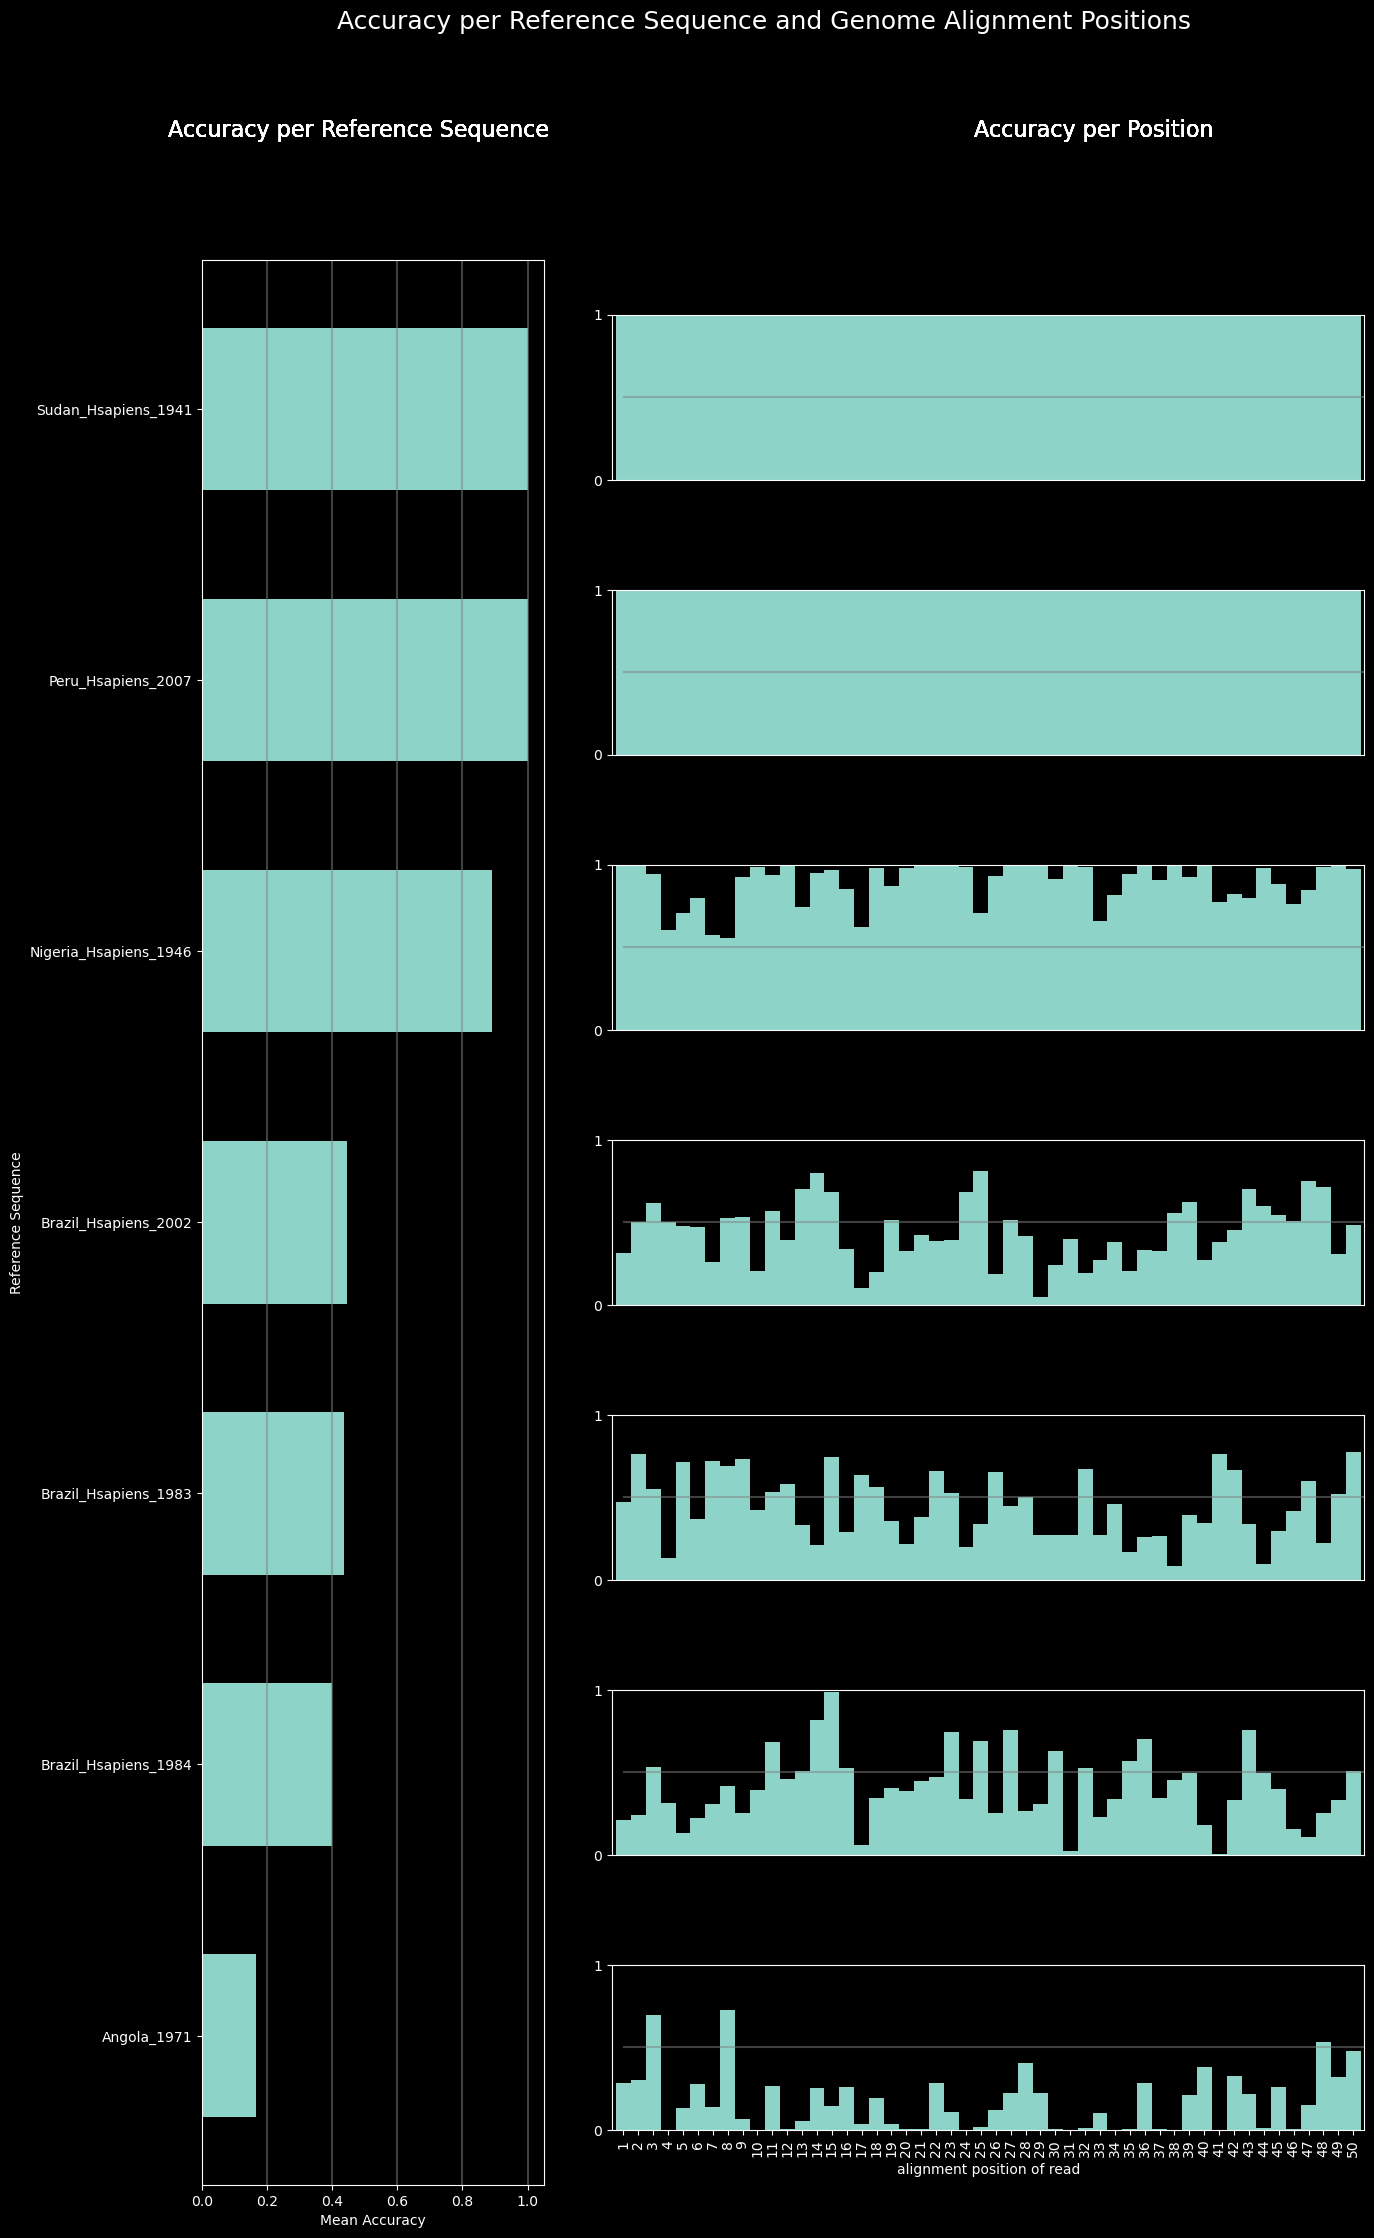

In [ ]:
stats = stats_per_refseq.loc[stats_per_refseq.mean_acc.notna(), :]
plot_accuracy(stats)

## Analysis of Label Probabilities

In [ ]:
aln.reset_iterator()
refseq_meta = aln.parse_header_reference_sequences()
print(refseq_meta[list(refseq_meta.keys())[0]])
print(refseq_meta['11089:ncbi:8']['organism'])
print(refseq_meta['11089:ncbi:8']['refseq_length'])

{'organism': 'Angola_1971', 'refseq_accession': 'AY968064', 'refseq_length': '10237', 'refseqid': '11089:ncbi:1', 'refseqnb': '1', 'refsource': 'ncbi', 'reftaxonomyid': '11089'}
ArD114896_Senegal_1995
10237


In [ ]:
p2db = Path('/mnt/s/metagentools/ncbi/infer_results/yf-ncbi/single_selected_7seq_150bp.db')
assert p2db.exists()
db = SqliteDatabase(p2db)

In [ ]:
db.print_schema()

predictions (table)
 columns: id, readid, refseqid, refsource, refseq_strand, taxonomyid, lbl_true, lbl_pred, pos_true, pos_pred, top_5_lbl_pred_0, top_5_lbl_pred_1, top_5_lbl_pred_2, top_5_lbl_pred_3, top_5_lbl_pred_4
 index: idx_preds_3
   indexed columns: readid, refseqid, pos_true
 index: idx_preds_refseqid
   indexed columns: refseqid

label_probabilities (table)
 columns: id, read_kmer_id, read_50mer_nb, refseqid, prob_000, prob_001, prob_002, prob_003, prob_004, prob_005, prob_006, prob_007, prob_008, prob_009, prob_010, prob_011, prob_012, prob_013, prob_014, prob_015, prob_016, prob_017, prob_018, prob_019, prob_020, prob_021, prob_022, prob_023, prob_024, prob_025, prob_026, prob_027, prob_028, prob_029, prob_030, prob_031, prob_032, prob_033, prob_034, prob_035, prob_036, prob_037, prob_038, prob_039, prob_040, prob_041, prob_042, prob_043, prob_044, prob_045, prob_046, prob_047, prob_048, prob_049, prob_050, prob_051, prob_052, prob_053, prob_054, prob_055, prob_056, prob_0

### Test the code with one "page" of data

Load a set of rows from `preds_probs` view for a specific reference sequence, and evaluate the metrics.

In [ ]:
selected_refseqs[-1]

'11089:ncbi:1'

In [ ]:
%%time
# Retrieve all columns and filtering on refseqid
# CPU times: user 973 ms, sys: 251 ms, total: 1.22 s
# Wall time: 2min 47s for 10,100 rows
# CPU times: user 954 ms, sys: 136 ms, total: 1.09 s
# Wall time: 17.5 s for 10100 with proper indexes
query = f"""
SELECT *
FROM preds_probs 
WHERE refseqid = '{selected_refseqs[-1]}'  
LIMIT 10100
"""
df_probs = db.get_dataframe(query)

print(df_probs.shape)
display(df_probs.tail())

(10100, 200)


,id,refseqid,lbl_true,lbl_pred,pos_true,pos_pred,top_5_lbl_pred_0,top_5_lbl_pred_1,top_5_lbl_pred_2,top_5_lbl_pred_3,...,prob_177,prob_178,prob_179,prob_180,prob_181,prob_182,prob_183,prob_184,prob_185,prob_186
10095,10096,11089:ncbi:1,118,2,4547,7,2,67,118,20,...,8.620532e-13,1.005013e-19,8.174250e-13,1.359655e-04,1.490946e-09,8.211846e-10,1.798794e-14,7.022321e-01,5.058082e-04,7.322818e-22
10096,10097,11089:ncbi:1,118,130,973,6,62,130,137,146,...,4.253266e-17,4.194007e-17,2.314456e-12,2.159869e-14,2.680717e-20,1.070130e-13,5.075820e-22,2.323057e-21,2.020265e-19,7.973730e-29
10097,10098,11089:ncbi:1,118,137,1225,8,143,46,67,160,...,6.268810e-12,2.985322e-20,3.350551e-21,4.574961e-22,1.049179e-19,1.894057e-28,9.187954e-24,7.252743e-21,1.306245e-08,5.765941e-27
10098,10099,11089:ncbi:1,118,102,8757,6,67,103,20,33,...,2.444246e-15,3.396491e-15,2.003567e-09,2.412583e-15,6.832757e-09,4.510508e-05,1.014253e-06,8.834100e-13,1.003908e-16,3.001064e-16
10099,10100,11089:ncbi:1,118,62,1183,4,93,62,104,16,...,1.350260e-05,6.829806e-09,2.644628e-11,9.000741e-20,3.008412e-14,4.175712e-15,1.764230e-04,1.418006e-17,1.011920e-17,9.009939e-22


CPU times: user 954 ms, sys: 136 ms, total: 1.09 s
Wall time: 17.5 s


Define lists of columns for different purposes:
- columns of interest
- columns for probabilities

Note: for some reason, pandas is not able to read some of the columns prob_i as float, so we force that

In [ ]:
view_cols = 'id,read_kmer_id,read_50mer_nb,refseqid,lbl_true,lbl_pred,pos_true,pos_pred,top_5_lbl_pred_0,top_5_lbl_pred_1,top_5_lbl_pred_2,top_5_lbl_pred_3,top_5_lbl_pred_4,prob_000,prob_001,prob_002,prob_003,prob_004,prob_005,prob_006,prob_007,prob_008,prob_009,prob_010,prob_011,prob_012,prob_013,prob_014,prob_015,prob_016,prob_017,prob_018,prob_019,prob_020,prob_021,prob_022,prob_023,prob_024,prob_025,prob_026,prob_027,prob_028,prob_029,prob_030,prob_031,prob_032,prob_033,prob_034,prob_035,prob_036,prob_037,prob_038,prob_039,prob_040,prob_041,prob_042,prob_043,prob_044,prob_045,prob_046,prob_047,prob_048,prob_049,prob_050,prob_051,prob_052,prob_053,prob_054,prob_055,prob_056,prob_057,prob_058,prob_059,prob_060,prob_061,prob_062,prob_063,prob_064,prob_065,prob_066,prob_067,prob_068,prob_069,prob_070,prob_071,prob_072,prob_073,prob_074,prob_075,prob_076,prob_077,prob_078,prob_079,prob_080,prob_081,prob_082,prob_083,prob_084,prob_085,prob_086,prob_087,prob_088,prob_089,prob_090,prob_091,prob_092,prob_093,prob_094,prob_095,prob_096,prob_097,prob_098,prob_099,prob_100,prob_101,prob_102,prob_103,prob_104,prob_105,prob_106,prob_107,prob_108,prob_109,prob_110,prob_111,prob_112,prob_113,prob_114,prob_115,prob_116,prob_117,prob_118,prob_119,prob_120,prob_121,prob_122,prob_123,prob_124,prob_125,prob_126,prob_127,prob_128,prob_129,prob_130,prob_131,prob_132,prob_133,prob_134,prob_135,prob_136,prob_137,prob_138,prob_139,prob_140,prob_141,prob_142,prob_143,prob_144,prob_145,prob_146,prob_147,prob_148,prob_149,prob_150,prob_151,prob_152,prob_153,prob_154,prob_155,prob_156,prob_157,prob_158,prob_159,prob_160,prob_161,prob_162,prob_163,prob_164,prob_165,prob_166,prob_167,prob_168,prob_169,prob_170,prob_171,prob_172,prob_173,prob_174,prob_175,prob_176,prob_177,prob_178,prob_179,prob_180,prob_181,prob_182,prob_183,prob_184,prob_185,prob_186'.split(',')
assert len(view_cols) == df_probs.shape[1]

In [ ]:
display(df_probs[view_cols].head())

,id,read_kmer_id,read_50mer_nb,refseqid,lbl_true,lbl_pred,pos_true,pos_pred,top_5_lbl_pred_0,top_5_lbl_pred_1,...,prob_177,prob_178,prob_179,prob_180,prob_181,prob_182,prob_183,prob_184,prob_185,prob_186
0,1,11089:ncbi:1-17000,0,11089:ncbi:1,118,10,7804,0,118,32,...,4.620669e-10,2.195646e-23,4.973716e-17,1.287073e-19,6.685301e-13,2.796299e-13,5.020673e-22,2.393255e-15,1.298766e-21,3.557021e-18
1,2,11089:ncbi:1-16999,0,11089:ncbi:1,118,2,6069,4,62,2,...,9.303694e-15,5.522096e-11,9.077740e-16,5.685052e-12,9.021820e-15,4.313646e-09,2.335988e-06,8.922423e-16,2.676930e-11,8.044394e-09
2,3,11089:ncbi:1-16998,0,11089:ncbi:1,118,144,5317,4,144,146,...,2.070324e-07,2.066216e-10,8.602851e-09,2.749270e-16,3.818876e-09,8.827278e-09,2.178763e-12,1.517998e-10,6.869064e-14,9.024393e-14
3,4,11089:ncbi:1-16997,0,11089:ncbi:1,118,32,1717,0,32,62,...,2.841831e-17,1.257724e-20,3.984798e-20,8.843543e-24,2.310843e-16,1.785395e-16,2.284211e-22,1.367643e-22,2.185023e-27,2.357869e-23
4,5,11089:ncbi:1-16996,0,11089:ncbi:1,118,118,9658,0,118,16,...,2.384261e-05,7.231542e-10,1.272906e-07,2.878808e-14,1.620230e-10,3.461863e-02,9.617226e-12,2.706786e-13,1.076152e-12,1.402150e-17


In [ ]:
coi = ['refseqid', 'read_kmer_id', 'read_50mer_nb', 'lbl_pred', 'pos_true']
prob_cols = [c for c in df_probs.columns if c.startswith('prob_')]

Add `accuracy` and `pos_bin`

In [ ]:
df_probs['accuracy'] = df_probs.lbl_true == df_probs.lbl_pred
coi.append('accuracy')

n_position_bins = 50
bins = [0 + n * 10237/n_position_bins for n in range(n_position_bins+1)]

df_probs['pos_bin'] = pd.cut(df_probs['pos_true'], bins, retbins=False)
df_probs.pos_bin.cat.categories = range(1, n_position_bins+1) # rename categories from 1 to n_position_bins
coi.append('pos_bin')
df_probs.loc[:,coi].head()

,refseqid,read_kmer_id,read_50mer_nb,lbl_pred,pos_true,accuracy,pos_bin
0,11089:ncbi:1,11089:ncbi:1-17000,0,10,7804,False,39
1,11089:ncbi:1,11089:ncbi:1-16999,0,2,6069,False,30
2,11089:ncbi:1,11089:ncbi:1-16998,0,144,5317,False,26
3,11089:ncbi:1,11089:ncbi:1-16997,0,32,1717,False,9
4,11089:ncbi:1,11089:ncbi:1-16996,0,118,9658,True,48


Create a DataFrame to keep the statistics for each "page":
- reads' count and sum of label probabilities for the whole "page"
- reads' count and sum of label probabilities for for each of the position bins

Once we have all the pages, we will be able to aggregate the statistics for the whole set of page together.
- total number of reads = $\sum_{pages}$ page read's counts
- mean label probability = $\sum_{pages}$ page read's sum of label probabilities / total number of reads
- same for each bin

In [ ]:
page_reads_stats_cols = 'reads_count reads_acc_sum'.split(' ')
page_reads_probs_cols = [f'reads_{p}_sum' for p in df_probs.columns if p.startswith('prob_')]  
page_bins_stats_cols = []
for b in range(1, n_position_bins+1):
    page_bins_stats_cols.append(f"bin{b:02d}_count")
    page_bins_stats_cols.extend([f'bin{b:02d}_{p}_sum' for p in df_probs.columns if p.startswith('prob_')])

page_stats_cols = page_reads_stats_cols + page_reads_probs_cols + page_bins_stats_cols

print(page_reads_stats_cols)
print(page_reads_probs_cols)
print(page_bins_stats_cols)
print(page_stats_cols[:10])
print(page_stats_cols[-10:])

df_page_stats = pd.DataFrame(columns=page_stats_cols)
display(df_page_stats.head())
print(df_page_stats.shape)

['reads_count', 'reads_acc_sum']
['reads_prob_000_sum', 'reads_prob_001_sum', 'reads_prob_002_sum', 'reads_prob_003_sum', 'reads_prob_004_sum', 'reads_prob_005_sum', 'reads_prob_006_sum', 'reads_prob_007_sum', 'reads_prob_008_sum', 'reads_prob_009_sum', 'reads_prob_010_sum', 'reads_prob_011_sum', 'reads_prob_012_sum', 'reads_prob_013_sum', 'reads_prob_014_sum', 'reads_prob_015_sum', 'reads_prob_016_sum', 'reads_prob_017_sum', 'reads_prob_018_sum', 'reads_prob_019_sum', 'reads_prob_020_sum', 'reads_prob_021_sum', 'reads_prob_022_sum', 'reads_prob_023_sum', 'reads_prob_024_sum', 'reads_prob_025_sum', 'reads_prob_026_sum', 'reads_prob_027_sum', 'reads_prob_028_sum', 'reads_prob_029_sum', 'reads_prob_030_sum', 'reads_prob_031_sum', 'reads_prob_032_sum', 'reads_prob_033_sum', 'reads_prob_034_sum', 'reads_prob_035_sum', 'reads_prob_036_sum', 'reads_prob_037_sum', 'reads_prob_038_sum', 'reads_prob_039_sum', 'reads_prob_040_sum', 'reads_prob_041_sum', 'reads_prob_042_sum', 'reads_prob_043_sum'

,reads_count,reads_acc_sum,reads_prob_000_sum,reads_prob_001_sum,reads_prob_002_sum,reads_prob_003_sum,reads_prob_004_sum,reads_prob_005_sum,reads_prob_006_sum,reads_prob_007_sum,...,bin50_prob_177_sum,bin50_prob_178_sum,bin50_prob_179_sum,bin50_prob_180_sum,bin50_prob_181_sum,bin50_prob_182_sum,bin50_prob_183_sum,bin50_prob_184_sum,bin50_prob_185_sum,bin50_prob_186_sum


(0, 9589)


Evaluate the page stats:
- full page stats
- bins stats on page

In [ ]:
# Full page stats
reads_count = df_probs['accuracy'].count()
reads_acc_sum = df_probs['accuracy'].sum()
reads_probs_sum = df_probs[prob_cols].sum(axis=0)
reads_probs_mean = reads_probs_sum / reads_count
print(f"{reads_count:,d} reads in this page with {reads_acc_sum:,d} read correctly predicted")
print(f"{reads_probs_sum.shape[0]} sum of label probabilities: {reads_probs_sum[115:120].values.tolist()}")
print(f"{reads_probs_mean.shape[0]} mean of label probabilities: {reads_probs_mean[116:121].values.tolist()}")

10,100 reads in this page with 1,749 read correctly predicted
187 sum of label probabilities: [7.699206538653257, 1.1111885032842446, 68.64555169647161, 792.4048255017151, 16.151510502688314]
187 mean of label probabilities: [0.00011001866369150936, 0.0067965892768783774, 0.07845592331700149, 0.0015991594557117142, 0.003212844237354981]


In [ ]:
# Bins stats on this page
group =df_probs.groupby('pos_bin')
bins_count = group['refseqid'].count()
print(f"Bins count:{bins_count.values.tolist()}")
print(f"Bins count total: {bins_count.sum():,d}")

bins_probs_sum = group[prob_cols].sum()
bins_probs_sum.index = [f"bin{b:02d}" for b in range(1, n_position_bins+1)]
print(bins_count.shape, bins_probs_sum.shape)
assert bins_count.shape[0] == bins_probs_sum.shape[0]
bins_count = bins_count.replace(0,1) # avoid division by zero
bins_probs_mean = bins_probs_sum.div(bins_count.values, axis=0)

display(bins_probs_mean.iloc[-10:, 25:35])

Bins count:[143, 204, 228, 178, 249, 224, 261, 180, 222, 215, 237, 201, 260, 129, 227, 191, 178, 276, 154, 167, 262, 274, 179, 178, 247, 226, 191, 155, 180, 202, 177, 227, 263, 142, 130, 238, 202, 321, 201, 204, 201, 191, 226, 251, 200, 119, 200, 178, 165, 46]
Bins count total: 10,100
(50,) (50, 187)


,prob_025,prob_026,prob_027,prob_028,prob_029,prob_030,prob_031,prob_032,prob_033,prob_034
bin41,0.033860,4.292160e-05,1.081754e-04,3.014234e-04,1.923684e-05,1.094278e-04,9.025497e-07,0.102705,2.322505e-02,3.880153e-07
bin42,0.000251,2.884665e-09,1.349935e-02,1.619128e-07,6.341153e-09,2.219937e-02,7.961802e-08,0.065824,2.738930e-05,5.488382e-09
bin43,0.000727,5.981819e-08,2.858063e-04,6.348454e-07,1.765665e-06,1.801872e-03,5.045747e-06,0.019567,2.543927e-02,2.858710e-05
bin44,0.002033,4.399186e-08,4.012524e-02,9.016969e-08,2.055729e-11,1.012344e-03,3.564649e-04,0.013228,6.437331e-06,1.235529e-08
bin45,0.000004,5.682799e-05,3.992345e-05,4.427748e-08,2.935962e-03,9.177757e-04,5.034762e-08,0.007261,7.501688e-05,5.319368e-03
bin46,0.000457,8.876163e-07,1.225059e-03,1.411203e-05,8.051469e-05,3.239863e-05,6.842344e-10,0.019705,4.613760e-05,3.374885e-04
bin47,0.000008,2.935413e-06,1.268106e-02,3.573139e-05,6.598457e-04,3.791944e-06,3.083463e-06,0.025407,2.226580e-07,2.353620e-08
bin48,0.000001,9.665832e-05,1.380042e-06,2.797769e-05,2.512720e-08,1.207554e-02,7.058454e-05,0.002360,9.211209e-05,8.439196e-06
bin49,0.005062,3.608192e-04,8.046562e-03,5.286867e-03,2.100409e-05,1.614819e-03,2.100263e-04,0.035602,3.778573e-05,3.652586e-05
bin50,0.000002,2.247467e-09,4.195001e-12,5.662693e-08,1.156842e-11,7.199091e-12,1.404310e-14,0.606148,1.625515e-05,1.925436e-09


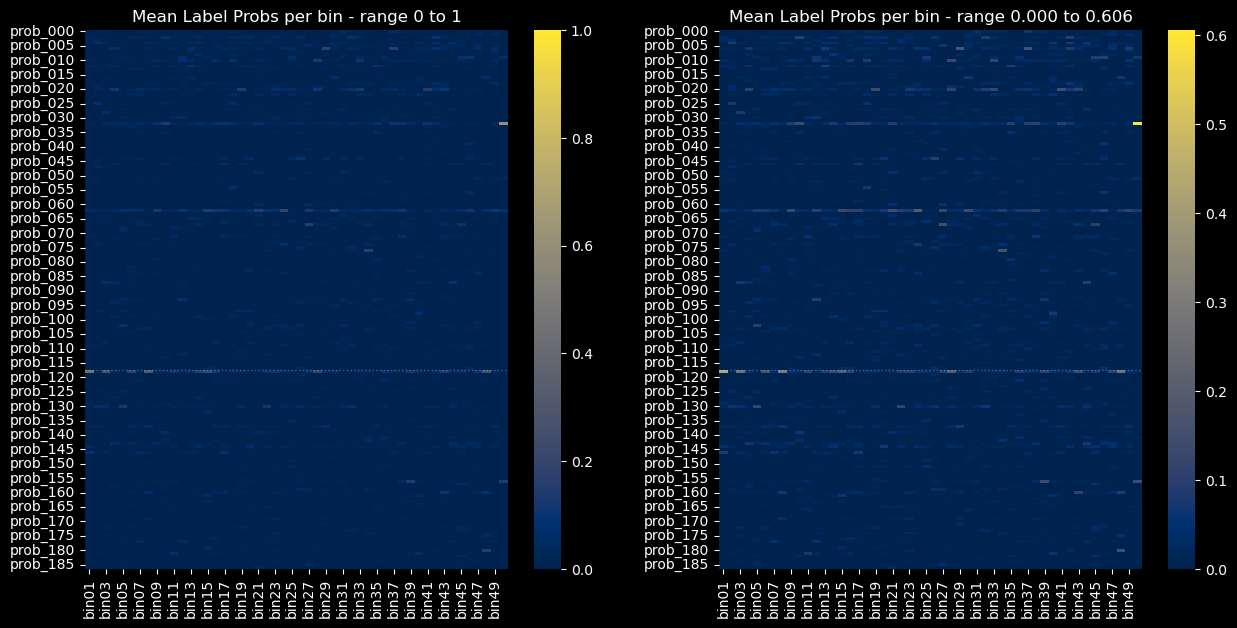

In [ ]:
fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize=(15,7))
bin_min = bins_probs_mean.min().min()
bin_max = bins_probs_mean.max().max()
ax1.set_title(f"Mean Label Probs per bin - range 0 to 1")
ax2.set_title(f"Mean Label Probs per bin - range {bin_min:.3f} to {bin_max:.3f}")
ax1.hlines(y=118, xmin=0, xmax=50, color='white', linewidth=1, linestyles='dotted', alpha=0.25)
ax2.hlines(y=118, xmin=0, xmax=50, color='white', linewidth=1, linestyles='dotted', alpha=0.25)
sns.heatmap(bins_probs_mean.T, ax=ax1, cmap='cividis', cbar=True, vmax=1., vmin=0.);
sns.heatmap(bins_probs_mean.T, ax=ax2, cmap='cividis', cbar=True);

We need to reshape `bins_probs_sum` to fit the `reads_prob_00i_sum` columns in `df_page_stats`:

In [ ]:
def flatten_probs(df):
    flattened_data = df.values.flatten()
    new_column_names = [f"{idx}_{col}" for idx in df.index for col in df.columns]
    return pd.DataFrame([flattened_data], columns=new_column_names)

cols = 'prob_000 prob_001 prob_002 prob_003 prob_004'.split(' ')
idx = 'bin01 bin02 bin03'.split(' ')
x = pd.DataFrame(np.arange(len(cols) * len(idx)).reshape(len(idx),len(cols)), columns=cols, index=idx)
display(x)
display(flatten_probs(x))
display(df_page_stats.iloc[0:1, 3 + 187:])

,prob_000,prob_001,prob_002,prob_003,prob_004
bin01,0,1,2,3,4
bin02,5,6,7,8,9
bin03,10,11,12,13,14


,bin01_prob_000,bin01_prob_001,bin01_prob_002,bin01_prob_003,bin01_prob_004,bin02_prob_000,bin02_prob_001,bin02_prob_002,bin02_prob_003,bin02_prob_004,bin03_prob_000,bin03_prob_001,bin03_prob_002,bin03_prob_003,bin03_prob_004
0,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14


,bin01_prob_000_sum,bin01_prob_001_sum,bin01_prob_002_sum,bin01_prob_003_sum,bin01_prob_004_sum,bin01_prob_005_sum,bin01_prob_006_sum,bin01_prob_007_sum,bin01_prob_008_sum,bin01_prob_009_sum,...,bin50_prob_177_sum,bin50_prob_178_sum,bin50_prob_179_sum,bin50_prob_180_sum,bin50_prob_181_sum,bin50_prob_182_sum,bin50_prob_183_sum,bin50_prob_184_sum,bin50_prob_185_sum,bin50_prob_186_sum


In [ ]:
flatten_probs(bins_probs_sum)

,bin01_prob_000,bin01_prob_001,bin01_prob_002,bin01_prob_003,bin01_prob_004,bin01_prob_005,bin01_prob_006,bin01_prob_007,bin01_prob_008,bin01_prob_009,...,bin50_prob_177,bin50_prob_178,bin50_prob_179,bin50_prob_180,bin50_prob_181,bin50_prob_182,bin50_prob_183,bin50_prob_184,bin50_prob_185,bin50_prob_186
0,0.018625,0.000792,3.582388,2.893361,1.514707,0.000156,2.250576,0.049481,0.004053,0.009723,...,0.000002,9.049625e-11,1.938021e-08,0.000781,6.169648e-09,3.467380e-08,1.503264e-11,5.230736e-07,5.760928e-08,7.316577e-11


In [ ]:
print(page_reads_stats_cols)
print(page_reads_probs_cols[:5])
print(page_bins_stats_cols[:5])

['reads_count', 'reads_acc_sum']
['reads_prob_000_sum', 'reads_prob_001_sum', 'reads_prob_002_sum', 'reads_prob_003_sum', 'reads_prob_004_sum']
['bin01_count', 'bin01_prob_000_sum', 'bin01_prob_001_sum', 'bin01_prob_002_sum', 'bin01_prob_003_sum']


Now we can update the stats in df_page_stats with the new values:
- build one row_page_stats for each page
- append the row_page_stats to df_page_stats for each page

In [ ]:
row_page_stats = pd.DataFrame(data=0, index=[0], columns=page_stats_cols)
row_page_stats.loc[0, page_reads_stats_cols] = [reads_count, reads_acc_sum]
assert len(page_reads_probs_cols) == len(reads_probs_sum)
row_page_stats.loc[0, page_reads_probs_cols] = reads_probs_sum.values
for b in range(n_position_bins):
    row_page_stats.loc[0, f"bin{b+1:02d}_count"] = bins_count.iloc[b]
    bin_probs_cols = [c for c in row_page_stats.columns if f"bin{b+1:02d}_prob_" in c]
    assert len(bin_probs_cols) == len(bins_probs_sum.iloc[b])
    row_page_stats.loc[0, bin_probs_cols] = bins_probs_sum.iloc[b].values


display(row_page_stats.loc[:, [c for c in row_page_stats.columns if 'count' in c]])
display(row_page_stats.loc[:, [c for c in row_page_stats.columns if '_prob_005' in c]])

,reads_count,bin01_count,bin02_count,bin03_count,bin04_count,bin05_count,bin06_count,bin07_count,bin08_count,bin09_count,...,bin41_count,bin42_count,bin43_count,bin44_count,bin45_count,bin46_count,bin47_count,bin48_count,bin49_count,bin50_count
0,10100,143,204,228,178,249,224,261,180,222,...,201,191,226,251,200,119,200,178,165,46


,reads_prob_005_sum,bin01_prob_005_sum,bin02_prob_005_sum,bin03_prob_005_sum,bin04_prob_005_sum,bin05_prob_005_sum,bin06_prob_005_sum,bin07_prob_005_sum,bin08_prob_005_sum,bin09_prob_005_sum,...,bin41_prob_005_sum,bin42_prob_005_sum,bin43_prob_005_sum,bin44_prob_005_sum,bin45_prob_005_sum,bin46_prob_005_sum,bin47_prob_005_sum,bin48_prob_005_sum,bin49_prob_005_sum,bin50_prob_005_sum
0,93.746996,0.000156,0.097369,0.000033,0.000295,0.022392,0.783679,0.062676,0.193361,1.783825,...,1.029517,1.368584,5.425226,9.498016,5.379764,0.02839,8.552927,0.000042,3.824379,0.000006


## Handle probabilities with Pages

In [ ]:
p2aln = pfs.data / 'ncbi/simreads/yf/single_69seq_150bp/single_69seq_150bp.aln'
assert p2aln.exists()
aln = AlnFileReader(p2aln)
refseq_metadata = aln.parse_header_reference_sequences()

In [ ]:
# selected_refseqs = ['11089:ncbi:10','11089:ncbi:13', '11089:ncbi:27' ,'11089:ncbi:30','11089:ncbi:37', '11089:ncbi:32', '11089:ncbi:35', '11089:ncbi:1' ]
print("Selected reference sequences:")
for rsid in selected_refseqs:
    print(f"    - {rsid:14s}:    {refseq_metadata[rsid]['organism']}")

Selected reference sequences:
    - 11089:ncbi:10 :    Peru_Hsapiens_2007
    - 11089:ncbi:13 :    Sudan_Hsapiens_1941
    - 11089:ncbi:30 :    Nigeria_Hsapiens_1946
    - 11089:ncbi:37 :    Brazil_Hsapiens_2002
    - 11089:ncbi:32 :    Brazil_Hsapiens_1983
    - 11089:ncbi:35 :    Brazil_Hsapiens_1984
    - 11089:ncbi:1  :    Angola_1971


In [ ]:
def fetch_df_page(db, refseqid, last_seen_id=None, limit=10):
    if last_seen_id:
        sql = f"""
        SELECT * FROM preds_probs
        WHERE refseqid = '{refseqid}' AND id > {last_seen_id}
        ORDER BY id ASC
        LIMIT {limit}
        """
    else:
        sql = f"""
        SELECT * FROM preds_probs
        WHERE refseqid = '{refseqid}'
        ORDER BY id ASC
        LIMIT {limit}
        """
    return db.get_dataframe(sql)

In [ ]:
p2db = Path('/mnt/s/metagentools/ncbi/infer_results/yf-ncbi/single_selected_7seq_150bp.db')
assert p2db.exists()
db = SqliteDatabase(p2db=p2db)
db.print_schema()

predictions (table)
 columns: id, readid, refseqid, refsource, refseq_strand, taxonomyid, lbl_true, lbl_pred, pos_true, pos_pred, top_5_lbl_pred_0, top_5_lbl_pred_1, top_5_lbl_pred_2, top_5_lbl_pred_3, top_5_lbl_pred_4
 index: idx_preds_3
   indexed columns: readid, refseqid, pos_true
 index: idx_preds_refseqid
   indexed columns: refseqid

label_probabilities (table)
 columns: id, read_kmer_id, read_50mer_nb, refseqid, prob_000, prob_001, prob_002, prob_003, prob_004, prob_005, prob_006, prob_007, prob_008, prob_009, prob_010, prob_011, prob_012, prob_013, prob_014, prob_015, prob_016, prob_017, prob_018, prob_019, prob_020, prob_021, prob_022, prob_023, prob_024, prob_025, prob_026, prob_027, prob_028, prob_029, prob_030, prob_031, prob_032, prob_033, prob_034, prob_035, prob_036, prob_037, prob_038, prob_039, prob_040, prob_041, prob_042, prob_043, prob_044, prob_045, prob_046, prob_047, prob_048, prob_049, prob_050, prob_051, prob_052, prob_053, prob_054, prob_055, prob_056, prob_0

In [ ]:
%%time
# With no composite index
# CPU times: user 2.79 s, sys: 1.25 s, total: 4.03 s
# Wall time: 6min 58s
# CPU times: user 10.3 s, sys: 1.1 s, total: 11.4 s
# Wall time: 1min 51s
for rsid in selected_refseqs[0:2]:
    print(rsid, refseq_metadata[rsid]['organism'])
    last_seen_id = None
    for i in range(2):
        print(f"Page {i+1} (id: {last_seen_id})")
        start_time = datetime.now()
        df = fetch_df_page(db, refseqid=rsid, last_seen_id=last_seen_id, limit=25250)
        display(df.tail(3))
        # print(df.shape)
        last_seen_id = df.iloc[-1,0]
        print(last_seen_id)
        print(f"{(datetime.now()-start_time).total_seconds():.1f} seconds")
    print()

11089:ncbi:10 Peru_Hsapiens_2007
Page 1 (id: None)


,id,refseqid,lbl_true,lbl_pred,pos_true,pos_pred,top_5_lbl_pred_0,top_5_lbl_pred_1,top_5_lbl_pred_2,top_5_lbl_pred_3,...,prob_177,prob_178,prob_179,prob_180,prob_181,prob_182,prob_183,prob_184,prob_185,prob_186
25247,1742248,11089:ncbi:10,118,118,5848,4,118,130,156,177,...,3.409263e-17,1.249136e-18,5.285488e-17,1.350795e-21,1.857007e-08,6.170517e-13,8.854706e-16,1.030758e-18,6.205543e-22,9.667734e-16
25248,1742249,11089:ncbi:10,118,118,3581,6,118,102,20,32,...,2.080065e-15,1.107599e-18,3.063467e-18,8.936780e-20,5.989704e-17,2.923832e-15,2.593282e-27,6.372109e-19,1.959979e-18,1.641311e-22
25249,1742250,11089:ncbi:10,118,118,34,9,118,62,44,32,...,2.148936e-14,1.841622e-20,1.034070e-12,3.871894e-16,2.962153e-19,8.199974e-20,7.926088e-23,2.374184e-13,2.199686e-15,2.953846e-20


1742250
11.9 seconds
Page 2 (id: 1742250)


,id,refseqid,lbl_true,lbl_pred,pos_true,pos_pred,top_5_lbl_pred_0,top_5_lbl_pred_1,top_5_lbl_pred_2,top_5_lbl_pred_3,...,prob_177,prob_178,prob_179,prob_180,prob_181,prob_182,prob_183,prob_184,prob_185,prob_186
25247,1767498,11089:ncbi:10,118,118,3669,6,118,130,46,9,...,1.787423e-17,4.073307e-26,2.020223e-13,9.973717e-15,1.412239e-15,1.864688e-13,6.663732e-28,2.091368e-17,1.803899e-22,3.238205e-28
25248,1767499,11089:ncbi:10,118,118,9171,8,118,160,67,103,...,9.139292e-19,1.532826e-20,6.314936e-23,8.049606e-17,1.620448e-25,1.095533e-26,2.193305e-26,2.392993e-18,2.503746e-17,2.779821e-33
25249,1767500,11089:ncbi:10,118,118,10020,9,118,32,62,135,...,1.190419e-14,8.011387e-30,3.914204e-24,2.504835e-25,3.223541e-19,8.215421e-25,5.398359e-25,4.221621e-24,3.999732e-21,1.388060e-31


1767500
44.2 seconds

11089:ncbi:13 Sudan_Hsapiens_1941
Page 1 (id: None)


,id,refseqid,lbl_true,lbl_pred,pos_true,pos_pred,top_5_lbl_pred_0,top_5_lbl_pred_1,top_5_lbl_pred_2,top_5_lbl_pred_3,...,prob_177,prob_178,prob_179,prob_180,prob_181,prob_182,prob_183,prob_184,prob_185,prob_186
25247,3459248,11089:ncbi:13,118,118,573,8,118,130,146,67,...,4.788658e-14,1.170171e-23,5.016542e-20,4.793501e-22,1.357801e-15,1.326641e-22,1.690231e-20,3.592389e-20,2.065754e-21,5.441170e-27
25248,3459249,11089:ncbi:13,118,118,6014,3,118,177,12,109,...,3.371561e-09,6.019572e-26,5.888047e-20,4.765773e-14,3.933271e-18,2.745805e-17,1.052744e-21,1.045276e-08,8.437952e-17,1.675176e-17
25249,3459250,11089:ncbi:13,118,118,3087,6,118,0,18,27,...,6.485062e-09,3.153904e-11,3.282344e-11,9.878778e-12,2.282005e-20,8.022896e-11,1.175741e-15,1.156485e-21,7.288513e-17,2.830148e-21


3459250
11.7 seconds
Page 2 (id: 3459250)


,id,refseqid,lbl_true,lbl_pred,pos_true,pos_pred,top_5_lbl_pred_0,top_5_lbl_pred_1,top_5_lbl_pred_2,top_5_lbl_pred_3,...,prob_177,prob_178,prob_179,prob_180,prob_181,prob_182,prob_183,prob_184,prob_185,prob_186
25247,3484498,11089:ncbi:13,118,118,4976,4,118,67,10,62,...,8.182090e-18,6.683293e-21,3.539135e-13,1.007867e-17,3.247110e-17,1.251630e-11,5.312824e-19,1.255436e-16,2.673427e-16,3.796977e-26
25248,3484499,11089:ncbi:13,118,118,8383,7,118,62,160,32,...,9.227114e-20,3.649366e-27,2.699216e-31,2.128359e-24,4.590484e-25,2.475068e-25,4.497406e-32,3.095737e-26,3.065751e-23,6.374945e-29
25249,3484500,11089:ncbi:13,118,118,8653,8,118,67,130,146,...,9.359256e-16,6.111803e-24,1.714922e-30,9.501512e-20,2.119203e-25,1.143005e-20,9.918874e-26,4.382713e-13,1.597690e-23,3.459854e-22


3484500
44.1 seconds

CPU times: user 10.3 s, sys: 1.1 s, total: 11.4 s
Wall time: 1min 51s


### Full paginated loop

In [ ]:
def handle_predictions(df):

    sequence_length = 10_237
    # define lists of columns for different purposes
    coi = ['refseqid', 'read_kmer_id', 'read_50mer_nb', 'lbl_pred', 'pos_true']
    prob_cols = [c for c in df.columns if c.startswith('prob_')]
    # Add accuracy and pos_bin
    df['accuracy'] = df.lbl_true == df.lbl_pred
    coi.append('accuracy')
    n_position_bins = 50
    bins = [0 + n * sequence_length/n_position_bins for n in range(n_position_bins+1)]
    df['pos_bin'] = pd.cut(df['pos_true'], bins, retbins=False)
    df.pos_bin.cat.categories = range(1, n_position_bins+1) # rename categories from 1 to n_position_bins
    coi.append('pos_bin')
    print("accuracy and pos_bin added")

    # create a dataframe to store page stats (df_page_stats)
    page_reads_stats_cols = 'reads_count reads_acc_sum'.split(' ')
    page_reads_probs_cols = [f'reads_{p}_sum' for p in df.columns if p.startswith('prob_')]  
    page_bins_stats_cols = []
    for b in range(1, n_position_bins+1):
        page_bins_stats_cols.append(f"bin{b:02d}_count")
        page_bins_stats_cols.extend([f'bin{b:02d}_{p}_sum' for p in df.columns if p.startswith('prob_')])

    page_stats_cols = page_reads_stats_cols + page_reads_probs_cols + page_bins_stats_cols

    df_page_stats = pd.DataFrame(columns=page_stats_cols)
    display(df_page_stats)

    # Evaluate full page stats
    reads_count = df['accuracy'].count()
    reads_acc_sum = df['accuracy'].sum()
    reads_probs_sum = df[prob_cols].sum(axis=0)
    reads_probs_mean = reads_probs_sum / reads_count

    # Evaluate bins stats for this page
    group =df.groupby('pos_bin')
    bins_count = group['refseqid'].count()
    bins_count = bins_count.replace(0,1) # avoid division by zero
    bins_probs_sum = group[prob_cols].sum()
    bins_probs_sum.index = [f"bin{b:02d}" for b in range(1, n_position_bins+1)]    
    bins_probs_mean = bins_probs_sum.div(bins_count.values, axis=0)

    # Create a row for df_page_stats
    
    # TODO: continue this function
    

In [ ]:
limit = 20250
reference_sequences = selected_refseqs[0:2]
for rsid in reference_sequences:
    print(rsid, refseq_metadata[rsid]['organism'])
    last_seen_id = None
    # TODO: replace by a WHILE rows_available, and when df has no rows, break
    for i in range(2):
        print(f"Page {i+1} (id: {last_seen_id})")
        start_time = datetime.now()
        df = fetch_df_page(db, refseqid=rsid, last_seen_id=last_seen_id, limit=limit)
        display(df.tail(3))
        # print(df.shape)
        last_seen_id = df.iloc[-1,0]
        print(last_seen_id)
        print(f"{(datetime.now()-start_time).total_seconds():.1f} seconds")
        df = handle_predictions

        
    print()

In [ ]:
limit = 25_250
reference_sequences = selected_refseqs[0:2]
for rsid in reference_sequences:
    print(rsid, refseq_metadata[rsid]['organism'])
    last_seen_id = None
    rows_available = True
    page = 1
    while rows_available:
        print(f"Page {i} (id: {last_seen_id})")
        start_time = datetime.now()
        df = fetch_df_page(db, refseqid=rsid, last_seen_id=last_seen_id, limit=limit)
        if df.shape[0] == 0:
            rows_available = False
            print('No more rows for', rsid)
            break
        else:
            i += 1
            display(df.tail(3))
            # print(df.shape)
            last_seen_id = df.iloc[-1,0]
            print(last_seen_id)
            print(f"{(datetime.now()-start_time).total_seconds():.1f} seconds")
            # df = handle_predictions

        
    print()

11089:ncbi:10 Peru_Hsapiens_2007
Page 1 (id: None)


,id,refseqid,lbl_true,lbl_pred,pos_true,pos_pred,top_5_lbl_pred_0,top_5_lbl_pred_1,top_5_lbl_pred_2,top_5_lbl_pred_3,...,prob_177,prob_178,prob_179,prob_180,prob_181,prob_182,prob_183,prob_184,prob_185,prob_186
25247,1742248,11089:ncbi:10,118,118,5848,4,118,130,156,177,...,3.409263e-17,1.249136e-18,5.285488e-17,1.350795e-21,1.857007e-08,6.170517e-13,8.854706e-16,1.030758e-18,6.205543e-22,9.667734e-16
25248,1742249,11089:ncbi:10,118,118,3581,6,118,102,20,32,...,2.080065e-15,1.107599e-18,3.063467e-18,8.936780e-20,5.989704e-17,2.923832e-15,2.593282e-27,6.372109e-19,1.959979e-18,1.641311e-22
25249,1742250,11089:ncbi:10,118,118,34,9,118,62,44,32,...,2.148936e-14,1.841622e-20,1.034070e-12,3.871894e-16,2.962153e-19,8.199974e-20,7.926088e-23,2.374184e-13,2.199686e-15,2.953846e-20


1742250
3.4 seconds
Page 2 (id: 1742250)


,id,refseqid,lbl_true,lbl_pred,pos_true,pos_pred,top_5_lbl_pred_0,top_5_lbl_pred_1,top_5_lbl_pred_2,top_5_lbl_pred_3,...,prob_177,prob_178,prob_179,prob_180,prob_181,prob_182,prob_183,prob_184,prob_185,prob_186
25247,1767498,11089:ncbi:10,118,118,3669,6,118,130,46,9,...,1.787423e-17,4.073307e-26,2.020223e-13,9.973717e-15,1.412239e-15,1.864688e-13,6.663732e-28,2.091368e-17,1.803899e-22,3.238205e-28
25248,1767499,11089:ncbi:10,118,118,9171,8,118,160,67,103,...,9.139292e-19,1.532826e-20,6.314936e-23,8.049606e-17,1.620448e-25,1.095533e-26,2.193305e-26,2.392993e-18,2.503746e-17,2.779821e-33
25249,1767500,11089:ncbi:10,118,118,10020,9,118,32,62,135,...,1.190419e-14,8.011387e-30,3.914204e-24,2.504835e-25,3.223541e-19,8.215421e-25,5.398359e-25,4.221621e-24,3.999732e-21,1.388060e-31


1767500
3.1 seconds
Page 3 (id: 1767500)


...

5100500
44.9 seconds
Page 135 (id: 5100500)


,id,refseqid,lbl_true,lbl_pred,pos_true,pos_pred,top_5_lbl_pred_0,top_5_lbl_pred_1,top_5_lbl_pred_2,top_5_lbl_pred_3,...,prob_177,prob_178,prob_179,prob_180,prob_181,prob_182,prob_183,prob_184,prob_185,prob_186
25247,5125748,11089:ncbi:13,118,118,5191,4,118,62,67,175,...,3.355883e-14,8.980523e-20,2.909407e-19,3.472261e-19,1.491577e-11,2.557080e-22,8.025019e-25,2.719219e-20,6.395048e-19,2.255532e-21
25248,5125749,11089:ncbi:13,118,118,1531,8,118,67,144,130,...,7.066355e-23,7.484147e-22,1.120228e-24,6.829331e-22,1.012696e-20,6.108887e-25,2.528013e-29,2.585432e-25,2.267194e-22,2.154765e-29
25249,5125750,11089:ncbi:13,118,118,8483,1,118,32,62,35,...,4.465266e-18,5.371363e-19,1.716287e-19,7.073084e-27,1.301756e-15,3.536311e-23,9.659595e-23,2.647038e-24,2.597709e-26,1.629396e-29


5125750
44.5 seconds
Page 136 (id: 5125750)


,id,refseqid,lbl_true,lbl_pred,pos_true,pos_pred,top_5_lbl_pred_0,top_5_lbl_pred_1,top_5_lbl_pred_2,top_5_lbl_pred_3,...,prob_177,prob_178,prob_179,prob_180,prob_181,prob_182,prob_183,prob_184,prob_185,prob_186
25247,5150998,11089:ncbi:13,118,118,4047,5,118,62,103,130,...,9.547133e-15,1.551983e-22,2.911031e-17,3.863124e-20,7.262302e-22,5.083557e-22,1.237242e-19,1.685325e-13,3.716271e-16,1.224146e-23
25248,5150999,11089:ncbi:13,118,118,673,0,118,46,67,62,...,2.426284e-21,4.219057e-26,6.627664e-19,2.820115e-15,5.094441e-17,1.094989e-22,2.356390e-25,1.337840e-18,1.793228e-18,1.466732e-24
25249,5151000,11089:ncbi:13,118,118,4056,5,118,62,103,130,...,2.971955e-10,1.609967e-17,3.725937e-15,4.541637e-08,9.826867e-17,1.457500e-16,1.434290e-14,3.545806e-11,2.713666e-10,4.182633e-24


5151000
44.8 seconds
Page 137 (id: 5151000)
No more rows for 11089:ncbi:13



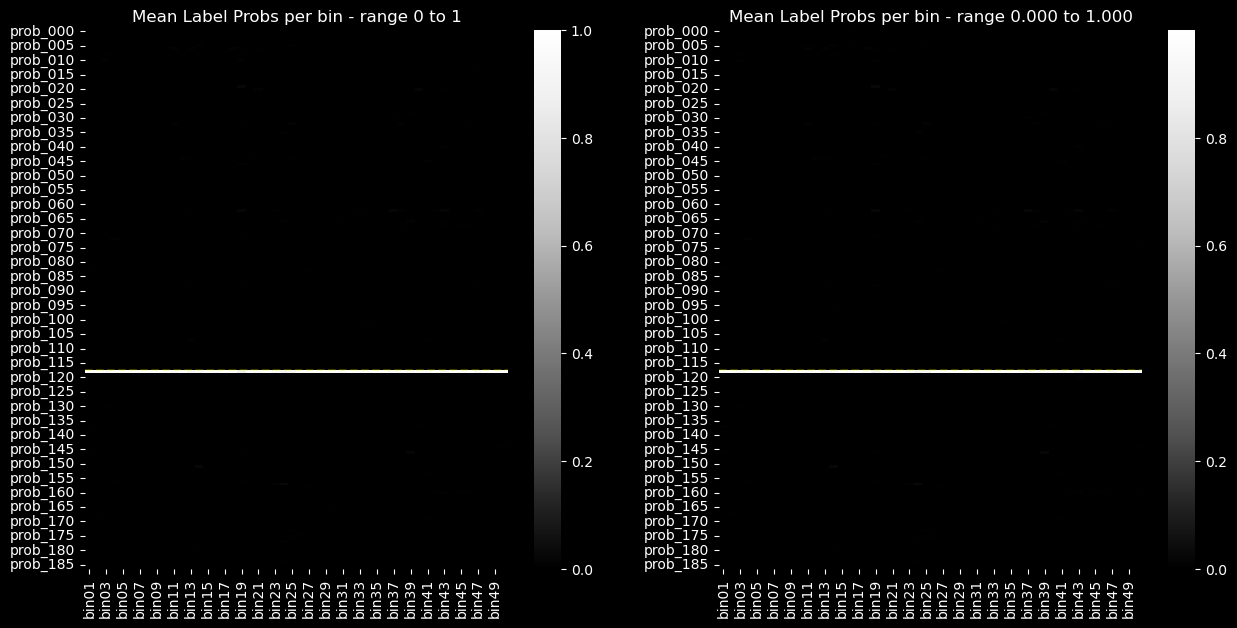

In [ ]:
fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize=(15,7))
bin_min = bins_probs_mean.min().min()
bin_max = bins_probs_mean.max().max()
ax1.set_title(f"Mean Label Probs per bin - range 0 to 1")
ax2.set_title(f"Mean Label Probs per bin - range {bin_min:.3f} to {bin_max:.3f}")
ax1.hlines(y=118, xmin=0, xmax=50, color='yellow', linestyles='dashed', alpha=0.25)
ax2.hlines(y=118, xmin=0, xmax=50, color='yellow', linestyles='dashed', alpha=0.25)
sns.heatmap(bins_probs_mean.T, ax=ax1, cmap='Greys_r', cbar=True, vmax=1, vmin=0);
sns.heatmap(bins_probs_mean.T, ax=ax2, cmap='Greys_r', cbar=True);

We need to reshape `bins_probs_sum` to fit the `reads_prob_00i_sum` columns in `df_page_stats`:

In [ ]:
def flatten_probs(df):
    flattened_data = df.values.flatten()
    new_column_names = [f"{idx}_{col}" for idx in df.index for col in df.columns]
    return pd.DataFrame([flattened_data], columns=new_column_names)

cols = 'prob_000 prob_001 prob_002 prob_003 prob_004'.split(' ')
idx = 'bin01 bin02 bin03'.split(' ')
x = pd.DataFrame(np.arange(len(cols) * len(idx)).reshape(len(idx),len(cols)), columns=cols, index=idx)
display(x)
display(flatten_probs(x))
display(df_page_stats.iloc[0:1, 3 + 187:])

,prob_000,prob_001,prob_002,prob_003,prob_004
bin01,0,1,2,3,4
bin02,5,6,7,8,9
bin03,10,11,12,13,14


,bin01_prob_000,bin01_prob_001,bin01_prob_002,bin01_prob_003,bin01_prob_004,bin02_prob_000,bin02_prob_001,bin02_prob_002,bin02_prob_003,bin02_prob_004,bin03_prob_000,bin03_prob_001,bin03_prob_002,bin03_prob_003,bin03_prob_004
0,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14


,bin01_prob_000_sum,bin01_prob_001_sum,bin01_prob_002_sum,bin01_prob_003_sum,bin01_prob_004_sum,bin01_prob_005_sum,bin01_prob_006_sum,bin01_prob_007_sum,bin01_prob_008_sum,bin01_prob_009_sum,...,bin50_prob_177_sum,bin50_prob_178_sum,bin50_prob_179_sum,bin50_prob_180_sum,bin50_prob_181_sum,bin50_prob_182_sum,bin50_prob_183_sum,bin50_prob_184_sum,bin50_prob_185_sum,bin50_prob_186_sum


In [ ]:
flatten_probs(bins_probs_sum)

,bin01_prob_000,bin01_prob_001,bin01_prob_002,bin01_prob_003,bin01_prob_004,bin01_prob_005,bin01_prob_006,bin01_prob_007,bin01_prob_008,bin01_prob_009,...,bin50_prob_177,bin50_prob_178,bin50_prob_179,bin50_prob_180,bin50_prob_181,bin50_prob_182,bin50_prob_183,bin50_prob_184,bin50_prob_185,bin50_prob_186
0,0.00067,4.741137e-07,0.000054,0.000121,0.014024,3.920837e-08,0.027131,2.758536e-08,4.979009e-09,1.204013e-07,...,3.626004e-08,1.077517e-12,1.923064e-08,4.523960e-10,7.825627e-09,1.458659e-08,9.383632e-11,0.000001,0.000128,1.813254e-09


In [ ]:
print(page_reads_stats_cols)
print(page_reads_probs_cols[:5])
print(page_bins_stats_cols[:5])

['reads_count', 'reads_acc_sum']
['reads_prob_000_sum', 'reads_prob_001_sum', 'reads_prob_002_sum', 'reads_prob_003_sum', 'reads_prob_004_sum']
['bin01_count', 'bin01_prob_000_sum', 'bin01_prob_001_sum', 'bin01_prob_002_sum', 'bin01_prob_003_sum']


Now we can update the stats in df_page_stats with the new values:
- build one row_page_stats for each page
- append the row_page_stats to df_page_stats for each page

In [ ]:
row_page_stats = pd.DataFrame(data=0, index=[0], columns=page_stats_cols)
row_page_stats.loc[0, page_reads_stats_cols] = [reads_count, reads_acc_sum]
assert len(page_reads_probs_cols) == len(reads_probs_sum)
row_page_stats.loc[0, page_reads_probs_cols] = reads_probs_sum.values
for b in range(n_position_bins):
    row_page_stats.loc[0, f"bin{b+1:02d}_count"] = bins_count.iloc[b]
    bin_probs_cols = [c for c in row_page_stats.columns if f"bin{b+1:02d}_prob_" in c]
    assert len(bin_probs_cols) == len(bins_probs_sum.iloc[b])
    row_page_stats.loc[0, bin_probs_cols] = bins_probs_sum.iloc[b].values


display(row_page_stats.loc[:, [c for c in row_page_stats.columns if 'count' in c]])
display(row_page_stats.loc[:, [c for c in row_page_stats.columns if '_prob_005' in c]])

,reads_count,bin01_count,bin02_count,bin03_count,bin04_count,bin05_count,bin06_count,bin07_count,bin08_count,bin09_count,...,bin41_count,bin42_count,bin43_count,bin44_count,bin45_count,bin46_count,bin47_count,bin48_count,bin49_count,bin50_count
0,25250,505,505,505,404,303,404,101,505,303,...,606,404,404,404,606,505,606,606,505,202


,reads_prob_005_sum,bin01_prob_005_sum,bin02_prob_005_sum,bin03_prob_005_sum,bin04_prob_005_sum,bin05_prob_005_sum,bin06_prob_005_sum,bin07_prob_005_sum,bin08_prob_005_sum,bin09_prob_005_sum,...,bin41_prob_005_sum,bin42_prob_005_sum,bin43_prob_005_sum,bin44_prob_005_sum,bin45_prob_005_sum,bin46_prob_005_sum,bin47_prob_005_sum,bin48_prob_005_sum,bin49_prob_005_sum,bin50_prob_005_sum
0,7.110216,3.920837e-08,0.015132,3.265128e-09,8.129643e-07,8.932029e-10,1.185902e-09,4.734942e-11,8.698869e-09,6.242393e-09,...,0.000049,4.995971e-08,0.000008,4.216251e-09,0.000005,7.711012e-07,0.000104,0.000002,1.093456e-08,0.006282


## Plot mean probabilities

In [ ]:
def plot_mean_probabilities(df, figsize=(15,3)):
    prob_cols = [c for c in df.columns if c.startswith('prob_')]
    mean_probs = df.loc[:, prob_cols].mean(axis=0)
    mean_probs.index = range(len(mean_probs))

    fig, ax = plt.subplots(1,1, figsize=figsize)
    mean_probs.plot(kind='bar', ax=ax)
    ax.vlines(x=118, ymin=0, ymax=1, colors='gray', alpha=0.5)
    ax.hlines(xmin=0, xmax=186, y=0.9, colors='gray', alpha=0.5)
    ax.set_ylim((0,1))
    plt.show()

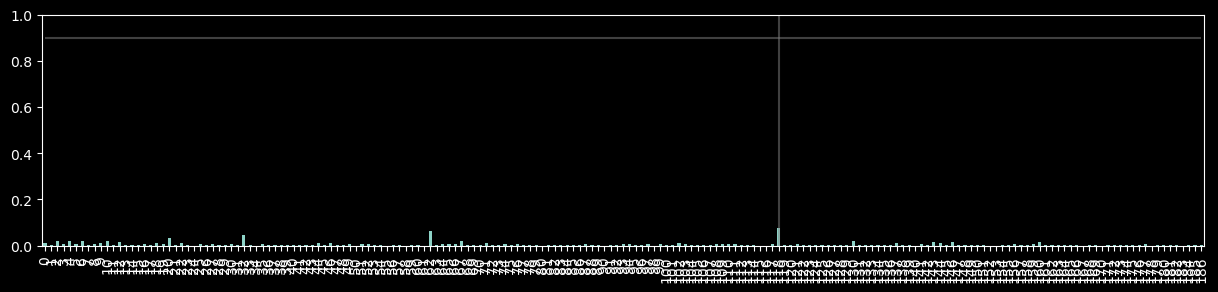

In [ ]:
plot_mean_probabilities(df_probs)

In [ ]:
# for b in sorted(df_probs.pos_bin.unique()):
#     plot_mean_probabilities(df_probs.loc[df_probs.pos_bin == b,:])

## Plot label probs per 50-mer read

In [ ]:
def plot_label_mean_probs(probs, pos_bin=None):
    nb_seq, _ , nb_lbls = probs.shape
    assert nb_lbls == 187
    fig = plt.figure(figsize=(16, 2 * nb_seq - 1));
    # fig.suptitle('Suptitle')
    axs = []
    for i in range(nb_seq):
        cmap = 'afmhot'  # 'YlOrRd_r' 'YlGn_r' 'PuBu' 'YlGnBu_r' 'afmhot'
        axs.append(plt.subplot2grid((nb_seq,1), (i,0), rowspan=1, colspan=1))
        # axs[i].axis('off')
        axs[i].imshow(probs[i,:,:], cmap=cmap, aspect='auto')
        axs[i].set_title(f"Mean 50-mer Probabilities (Position bin: {pos_bin if pos_bin else 'all'})")

    fig.subplots_adjust(top=1.5, bottom=0.2, hspace=0.5)
    plt.show()

# plot_label_mean_probs(np.expand_dims(dfdf.values, 0))

In [ ]:
dfdf = df_probs[prob_cols+['read_50mer_nb']].groupby('read_50mer_nb').mean()
df_probs.shape, dfdf.shape

((50500, 202), (101, 187))

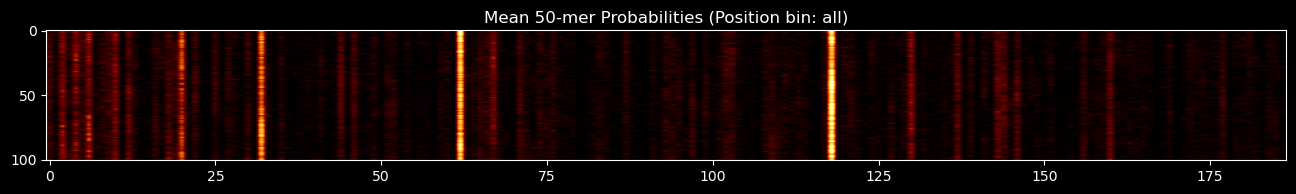

In [ ]:
plot_label_mean_probs(np.expand_dims(dfdf.values, 0))

In [ ]:
dfdfdf = df_probs[['pos_bin', 'read_50mer_nb'] + prob_cols].groupby(['pos_bin', 'read_50mer_nb']).mean()

In [ ]:
dfdfdf.loc[(1, slice(None)), :]

prob_000      prob_001  prob_002      prob_003  \
pos_bin read_50mer_nb                                                       
1       0              5.067904e-05  5.993972e-07  0.017199  4.108684e-09   
        1              2.526477e-07  1.366579e-12  0.074097  5.335485e-08   
        2              2.320591e-05  6.127543e-12  0.033168  7.637674e-05   
        3              1.168287e-07  6.736310e-11  0.065980  5.918660e-05   
        4              1.327895e-08  6.917753e-09  0.001716  1.552400e-08   
...                             ...           ...       ...           ...   
        96             1.996202e-07  5.894185e-05  0.172780  4.372350e-08   
        97             1.450459e-06  1.508041e-10  0.009056  2.811314e-08   
        98             5.529503e-06  7.030084e-08  0.000955  2.915940e-07   
        99             3.899877e-05  1.984825e-06  0.044094  1.603227e-07   
        100            5.193669e-06  1.907886e-06  0.005791  5.129502e-09   

                       prob_004      prob_005      prob_006      prob_007  \
pos_bin read_50mer_nb                                                       
1       0              0.030113  3.406494e-10  6.017990e-07  2.458540e-06   
        1              0.000001  2.484385e-08  2.760795e-08  4.262330e-04   
        2              0.000039  1.602084e-08  7.263936e-05  3.908913e-03   
        3              0.000347  6.870188e-09  9.410992e-07  1.186960e-05   
        4              0.115106  4.266132e-13  1.991560e-07  9.696282e-09   
...                         ...           ...           ...           ...   
        96             0.032079  3.209101e-06  9.933687e-08  1.633060e-09   
        97             0.001369  7.731129e-04  1.140941e-08  7.864150e-08   
        98             0.007308  3.808865e-07  3.101433e-05  2.010219e-07   
        99             0.012434  4.239362e-09  6.518161e-06  1.253214e-07   
        100            0.002836  1.029941e-05  7.818632e-08  7.323236e-11   

                           prob_008      prob_009  ...      prob_177  \
pos_bin read_50mer_nb                              ...                 
1       0              9.286059e-10  4.510764e-08  ...  1.731345e-08   
        1              2.129618e-11  2.375891e-10  ...  1.369647e-08   
        2              3.295860e-12  5.230509e-09  ...  6.435008e-03   
        3              3.683200e-08  2.655489e-09  ...  3.453928e-04   
        4              8.262650e-09  6.029276e-08  ...  1.030558e-08   
...                             ...           ...  ...           ...   
        96             9.996333e-07  2.790312e-03  ...  2.802706e-03   
        97             1.590303e-08  3.294723e-08  ...  5.284202e-06   
        98             9.188743e-09  8.298832e-09  ...  3.492986e-06   
        99             2.147930e-07  8.098762e-08  ...  5.671781e-04   
        100            1.862649e-09  3.159331e-07  ...  2.622214e-05   

                           prob_178      prob_179      prob_180      prob_181  \
pos_bin read_50mer_nb                                                           
1       0              1.447166e-07  7.210717e-07  4.998805e-12  7.880604e-07   
        1              3.788906e-09  3.954021e-10  3.931263e-09  3.272376e-11   
        2              2.665808e-06  6.245586e-09  6.074816e-14  3.280704e-10   
        3              9.849925e-08  2.264858e-09  8.039886e-10  3.435533e-08   
        4              3.549616e-09  1.533239e-09  7.161604e-10  3.144220e-11   
...                             ...           ...           ...           ...   
        96             2.651745e-11  1.515620e-06  4.767635e-02  3.936595e-10   
        97             1.192783e-10  9.582923e-11  1.141276e-01  3.386189e-12   
        98             2.464075e-11  8.531349e-08  7.383371e-04  2.001050e-11   
        99             2.511018e-09  2.728945e-09  3.014377e-08  5.371723e-04   
        100            1.815038e-07  3.390525e-08  1.451902e-04  8.455052e-11   

                           prob_

In [ ]:
dfdfdf.loc[(slice(None), 0), :].head()

,,prob_000,prob_001,prob_002,prob_003,prob_004,prob_005,prob_006,prob_007,prob_008,prob_009,...,prob_177,prob_178,prob_179,prob_180,prob_181,prob_182,prob_183,prob_184,prob_185,prob_186
pos_bin,read_50mer_nb,,,,,,,,,,,,,,,,,,,,,
1,0,5.067904e-05,5.993972e-07,1.719878e-02,4.108684e-09,0.030113,3.406494e-10,6.017990e-07,2.458540e-06,9.286059e-10,4.510764e-08,...,1.731345e-08,1.447166e-07,7.210717e-07,4.998805e-12,7.880604e-07,4.579868e-09,4.585445e-13,5.878870e-10,2.154018e-13,1.821190e-11
2,0,5.122645e-07,4.062378e-05,8.950027e-05,1.219833e-03,0.000864,9.651420e-06,8.066119e-07,4.593035e-04,1.560989e-03,1.882731e-08,...,7.536068e-09,5.849848e-05,4.547258e-06,4.452349e-08,4.829858e-09,3.745027e-07,2.406230e-06,6.322227e-09,1.141457e-04,1.019268e-09
3,0,9.353386e-04,3.238074e-06,2.780455e-08,1.033361e-09,0.075079,1.406227e-09,2.695516e-05,1.454708e-11,5.714326e-08,6.951616e-08,...,1.568796e-07,1.766685e-08,3.185508e-05,3.761685e-03,1.847326e-06,3.228750e-12,1.064687e-10,9.910607e-06,4.568835e-08,8.199399e-08
4,0,2.168899e-02,1.835682e-06,2.344609e-06,2.361963e-08,0.000074,2.477134e-10,2.803866e-02,6.776841e-12,8.965831e-07,2.890712e-03,...,3.401127e-06,8.500062e-08,1.474403e-10,1.720545e-11,2.871227e-07,2.503385e-07,2.017946e-07,1.891762e-06,7.317120e-11,1.186656e-11
5,0,9.250908e-10,2.265166e-09,1.277759e-05,1.378406e-07,0.001523,6.527713e-08,8.068590e-04,1.972146e-05,4.359873e-12,1.001727e-01,...,2.155008e-03,2.661414e-12,7.364066e-06,4.405080e-10,6.813264e-09,9.903893e-02,1.633508e-15,7.138325e-06,1.135666e-06,5.958216e-06


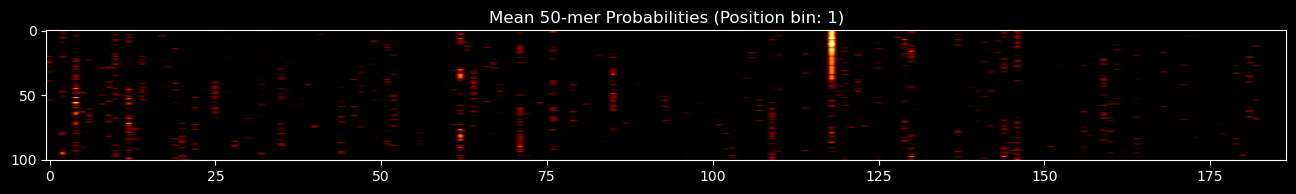

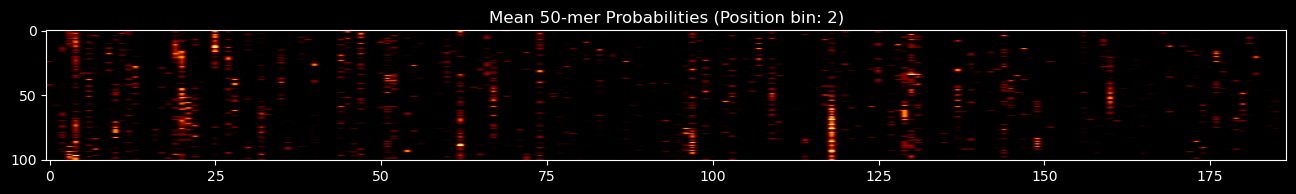

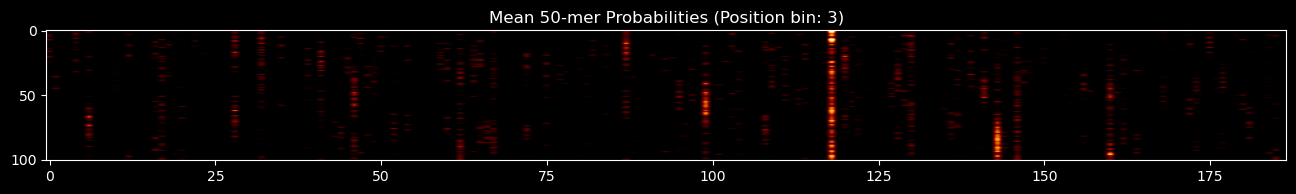

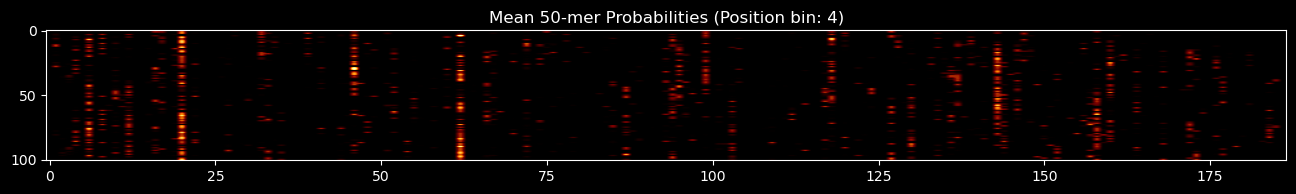

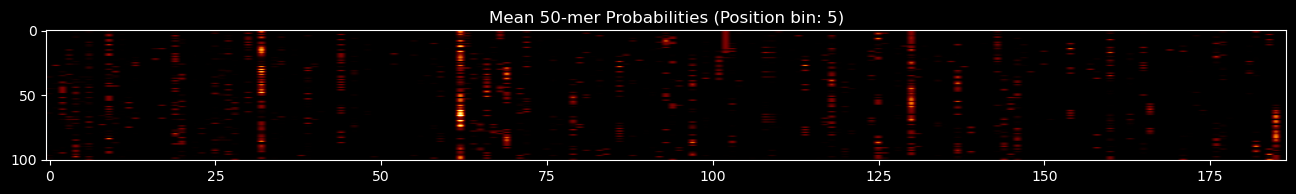

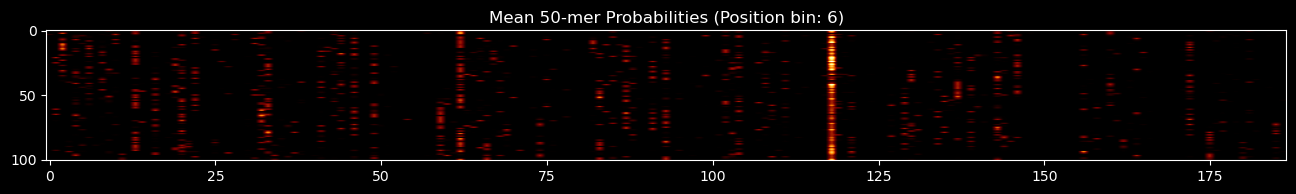

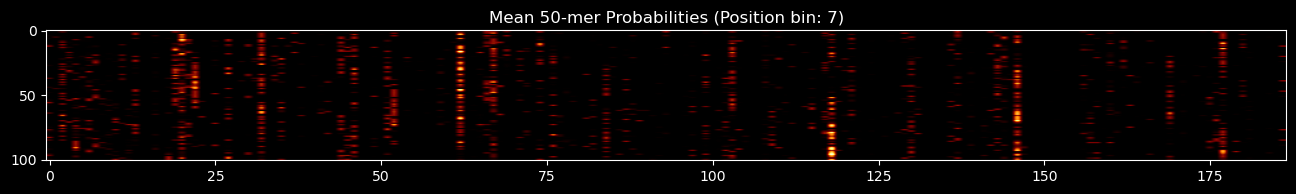

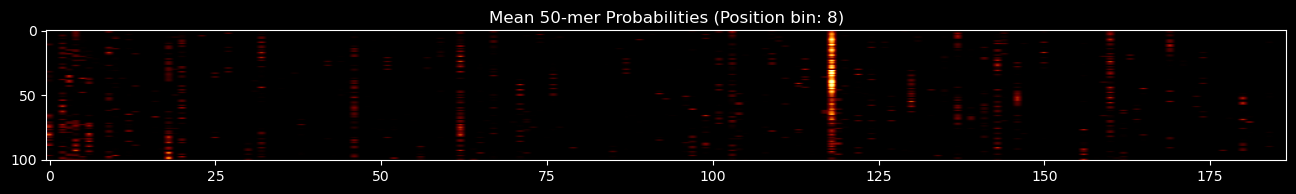

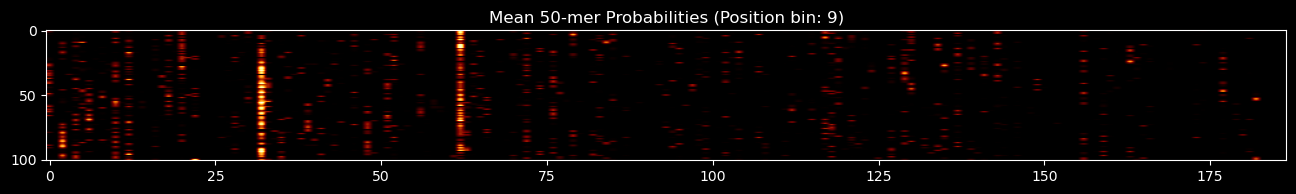

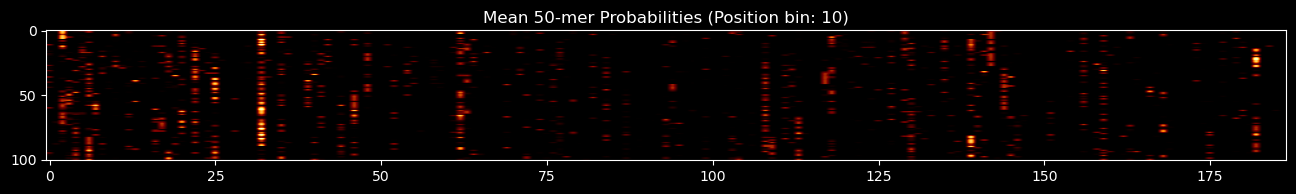

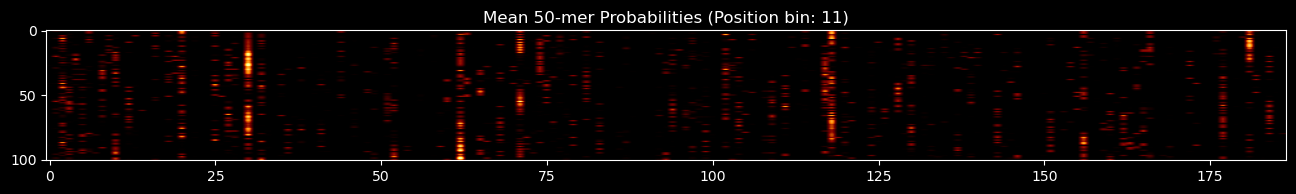

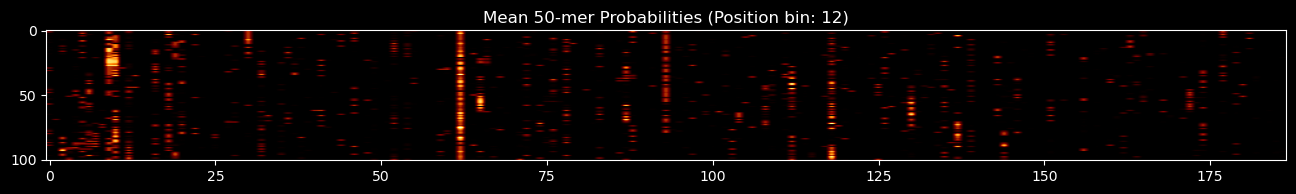

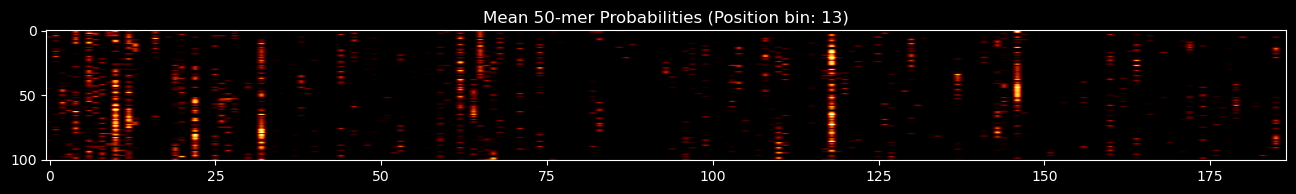

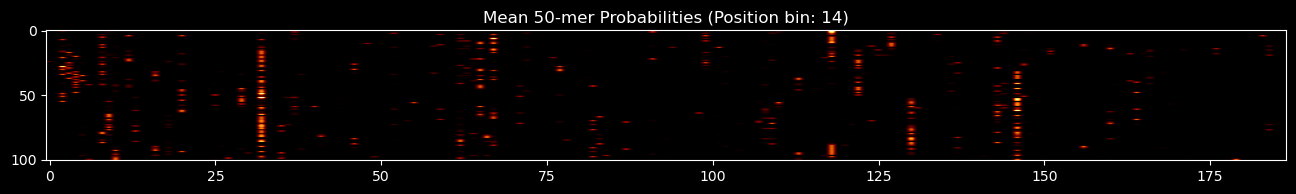

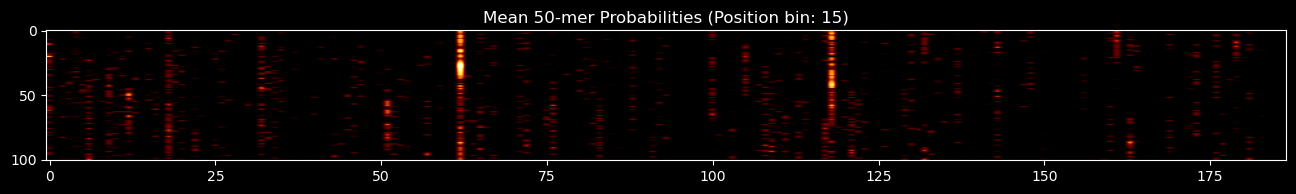

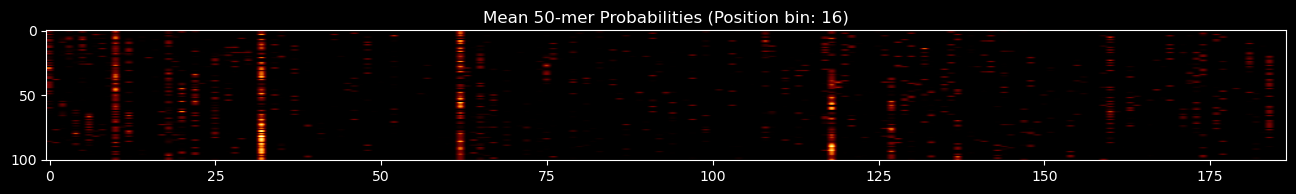

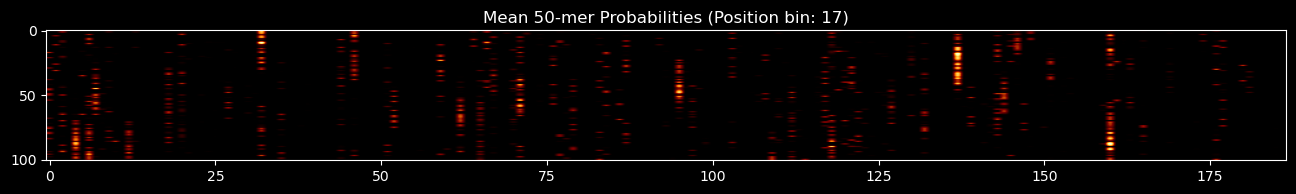

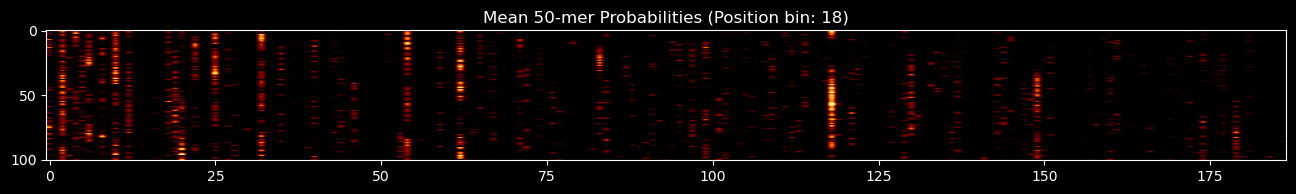

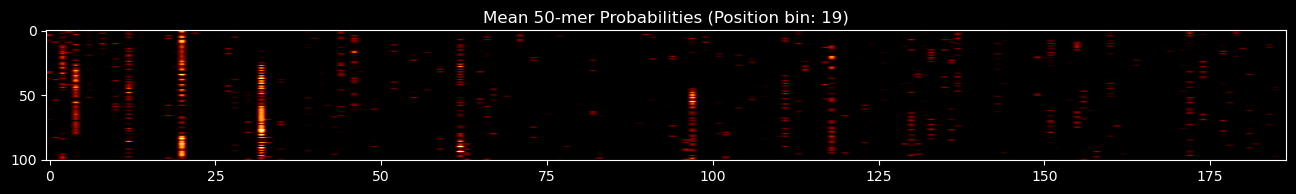

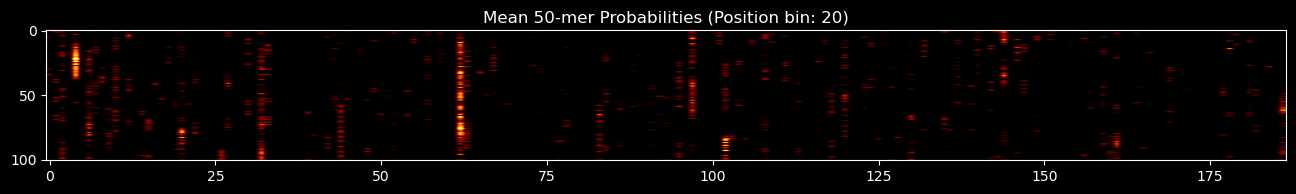

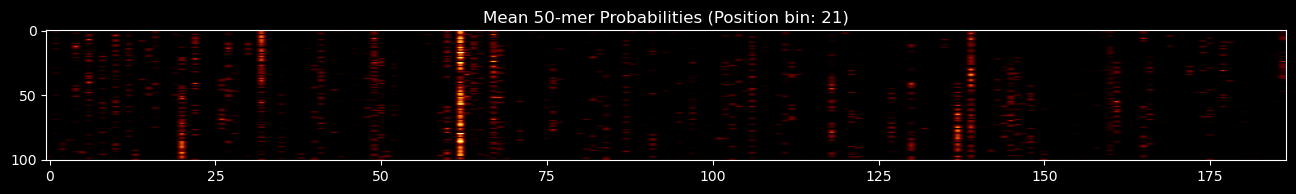

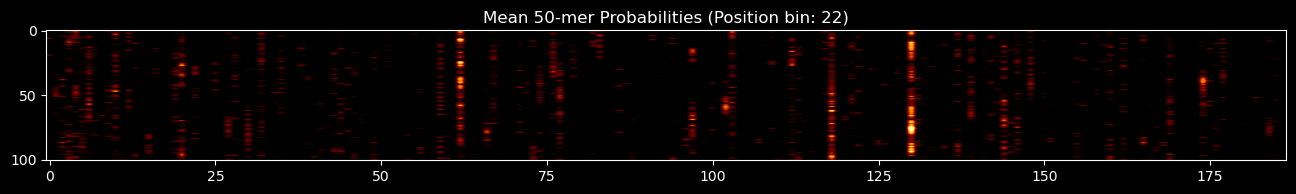

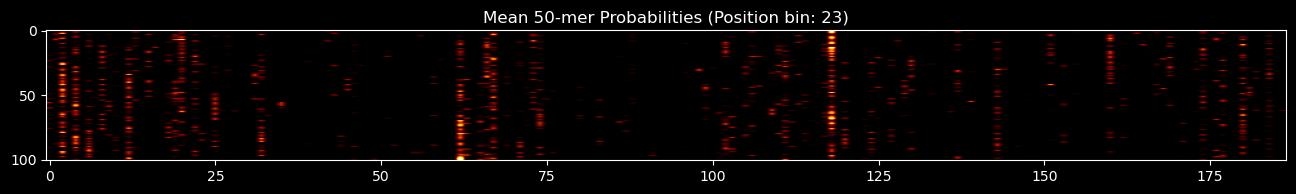

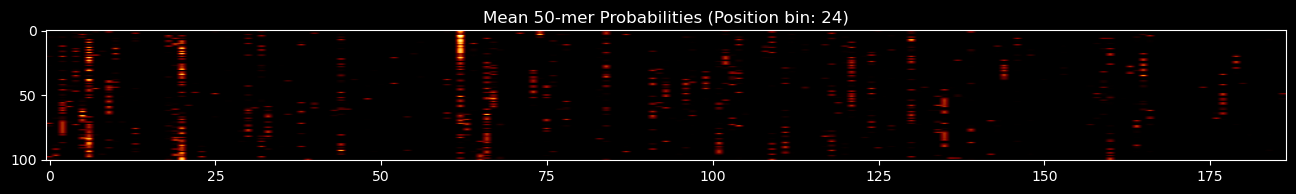

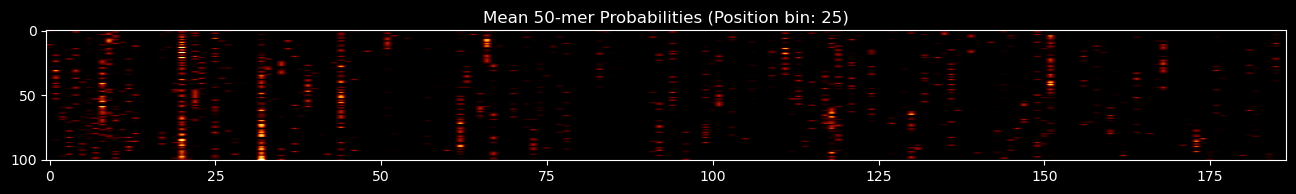

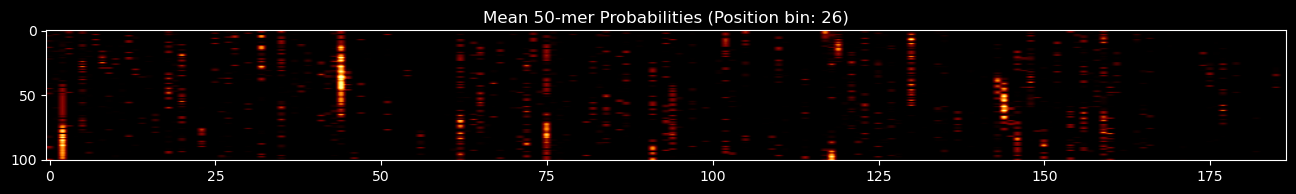

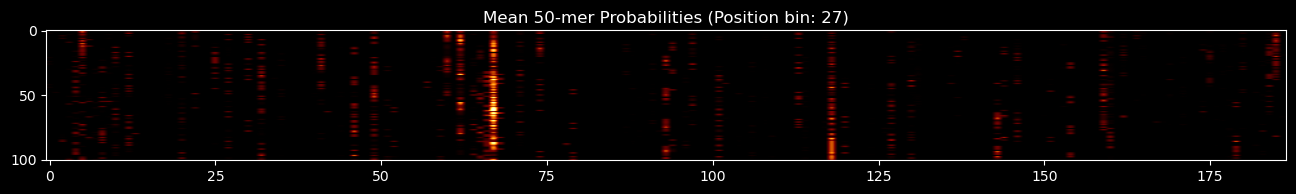

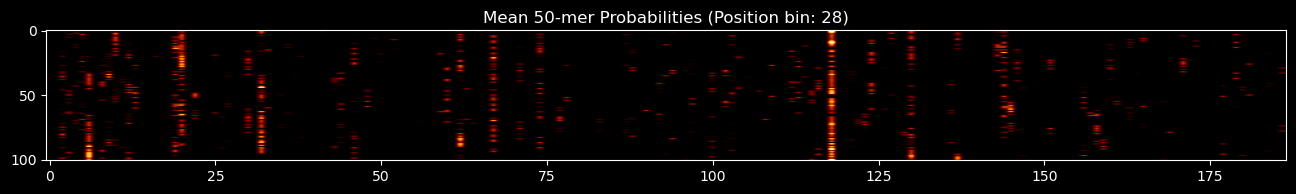

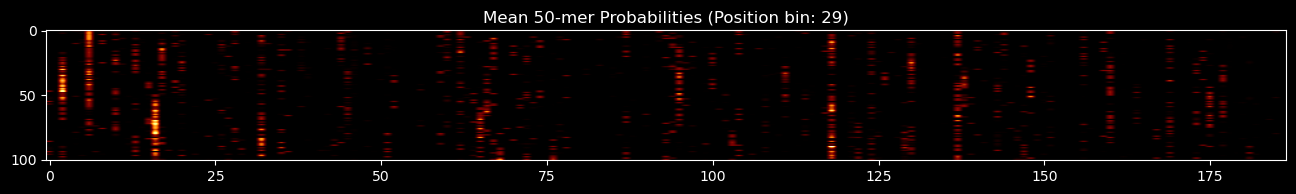

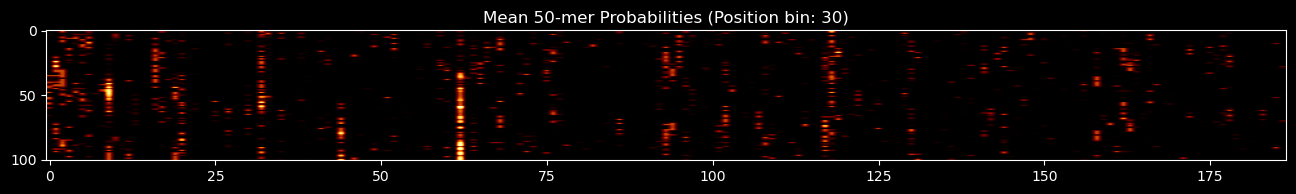

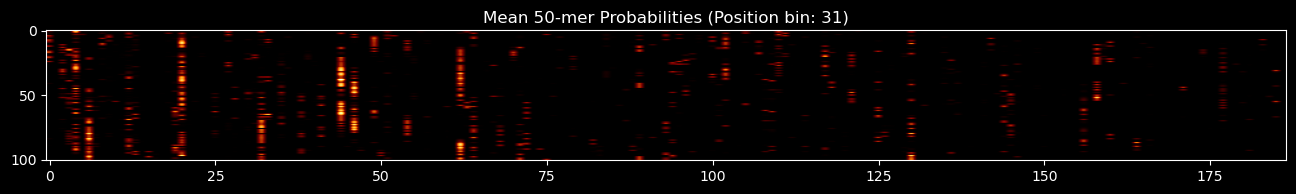

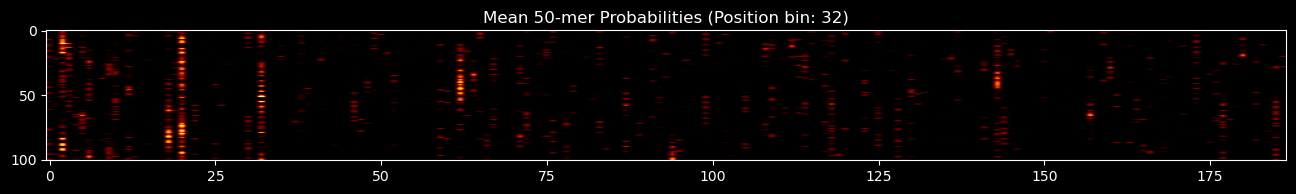

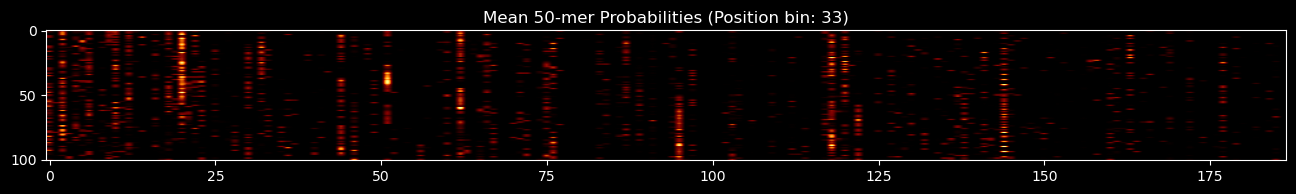

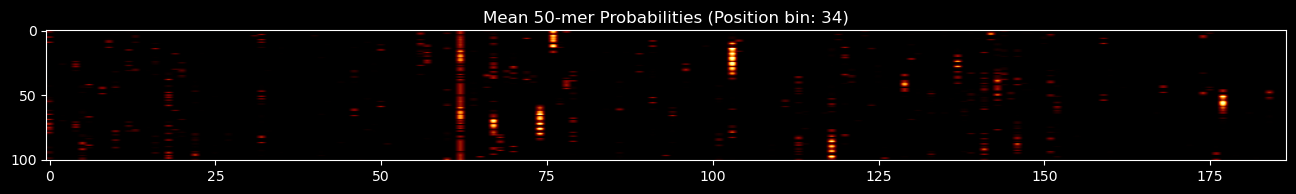

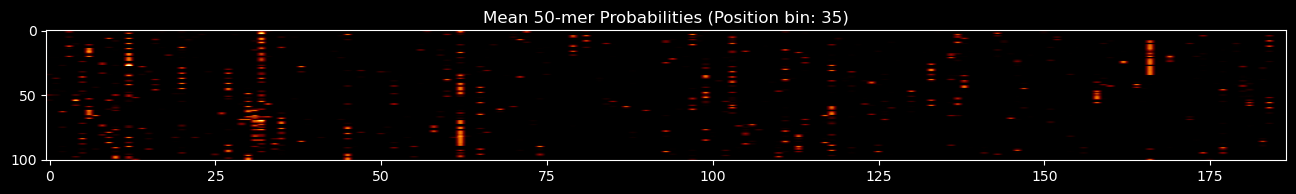

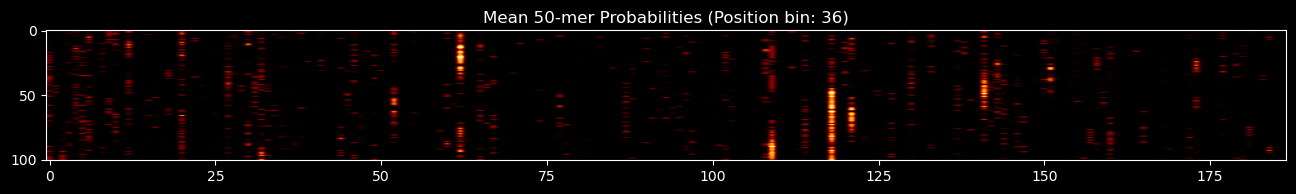

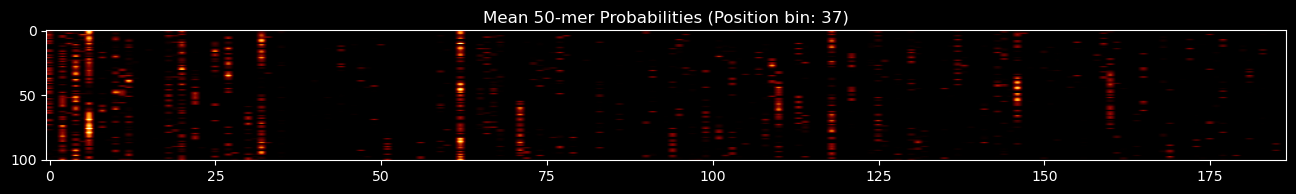

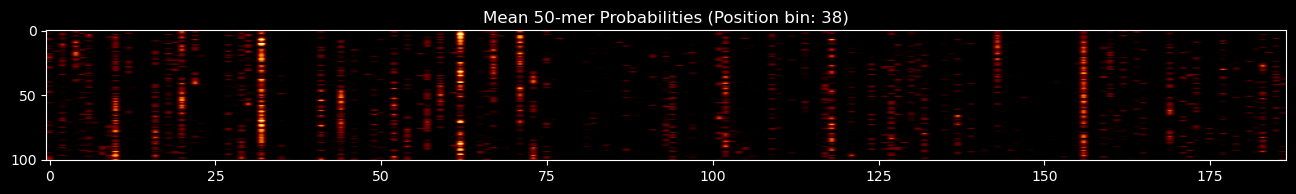

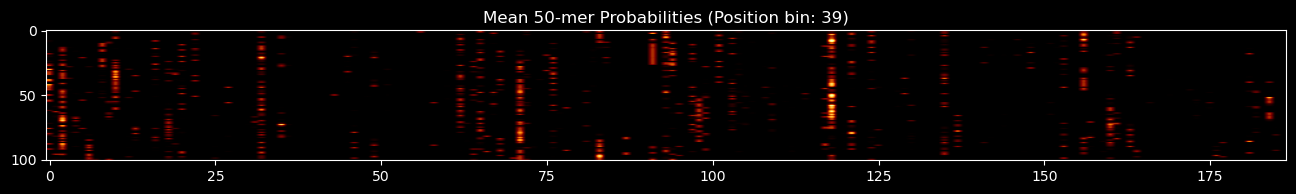

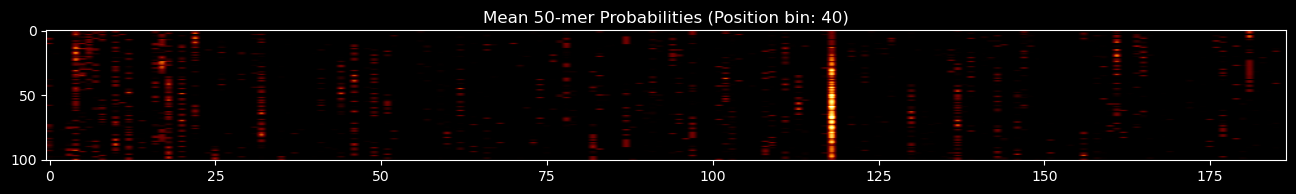

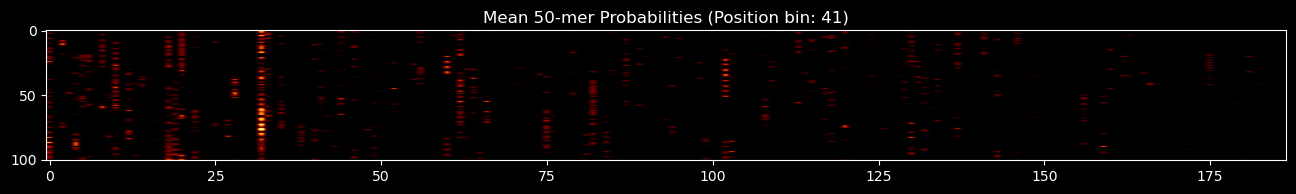

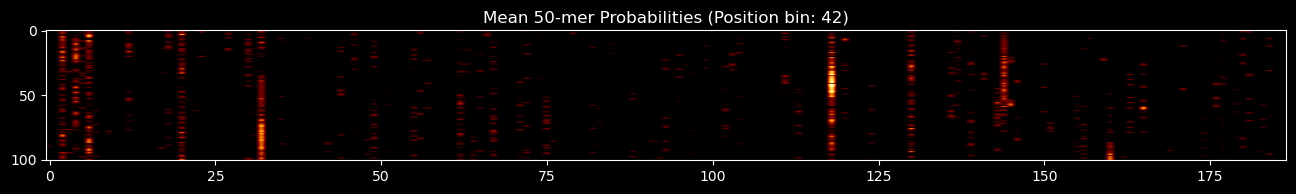

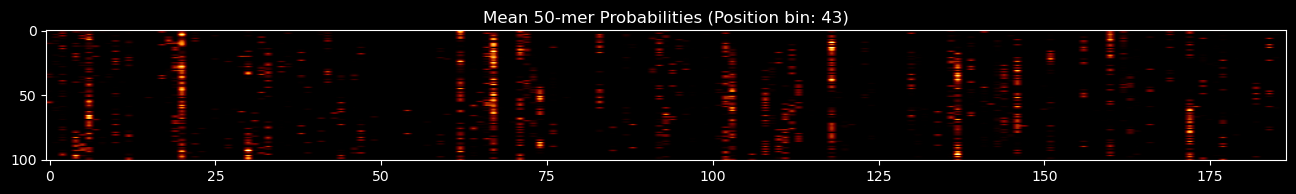

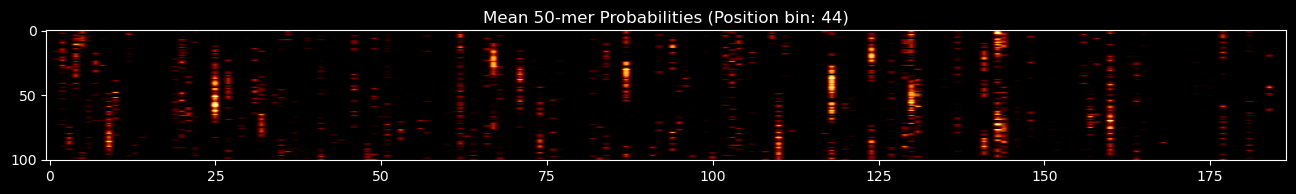

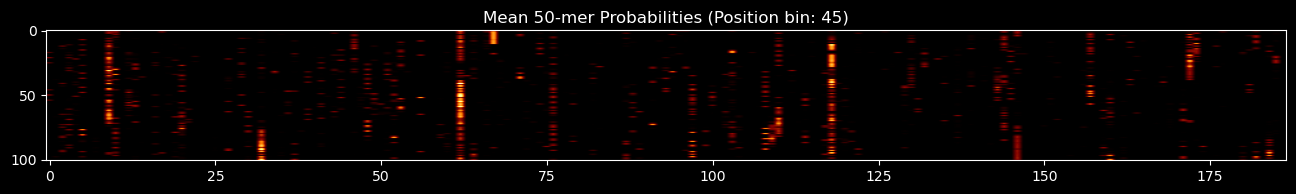

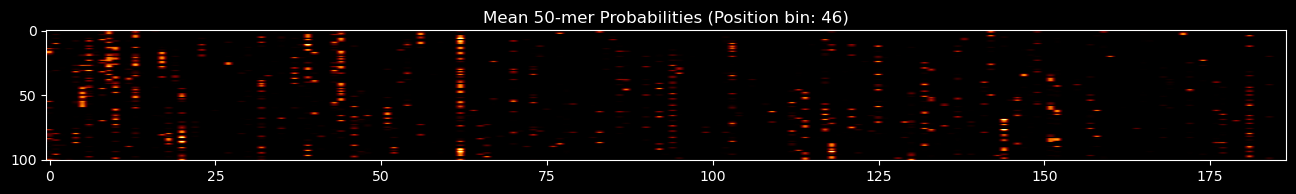

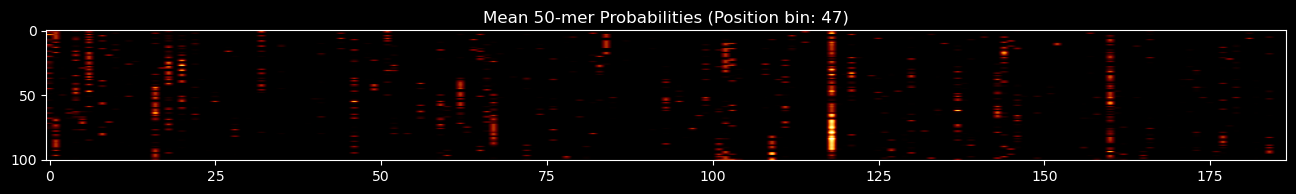

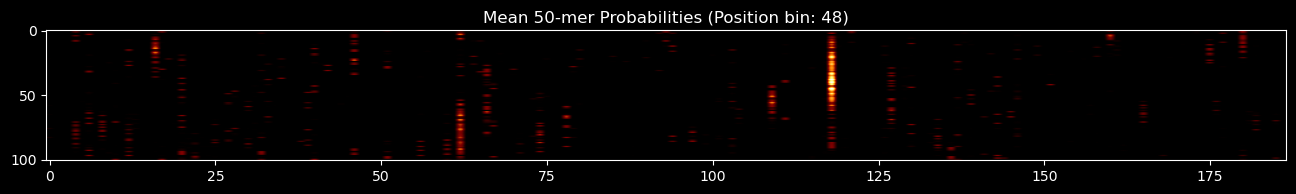

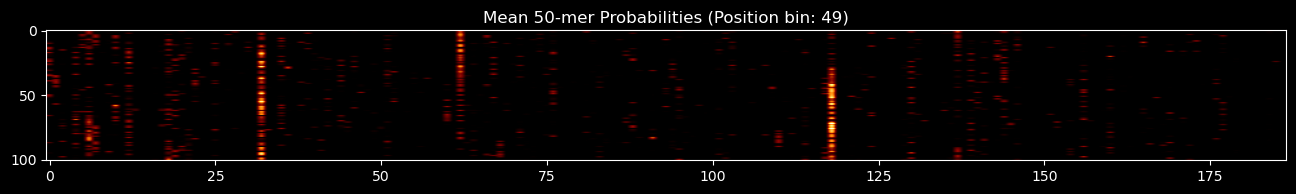

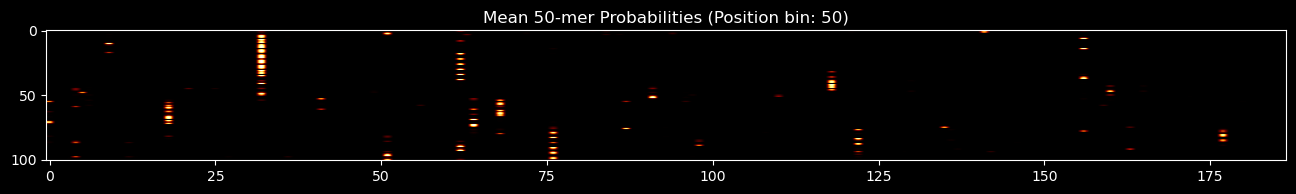

In [ ]:
for i in range(1,51):
    plot_label_mean_probs(np.expand_dims(dfdfdf.loc[(i, slice(None)), :].values, 0), pos_bin=i)

In [ ]:
ollbl = OriginalLabels()
ollbl.label2species(32)

'Human_gammaherpesvirus_8'

In [ ]:
i = 2
counts, np.argmax(counts), np.argpartition(counts, -i)[-i]

(array([ 2,  1,  1,  1,  8, 28,  1,  5,  9,  4,  7,  7,  1,  2,  1,  6,  4,
         1,  1,  5,  1,  1,  4]),
 5,
 8)

118 Yellow_fever_virus  |  62 Human_gammaherpesvirus_4


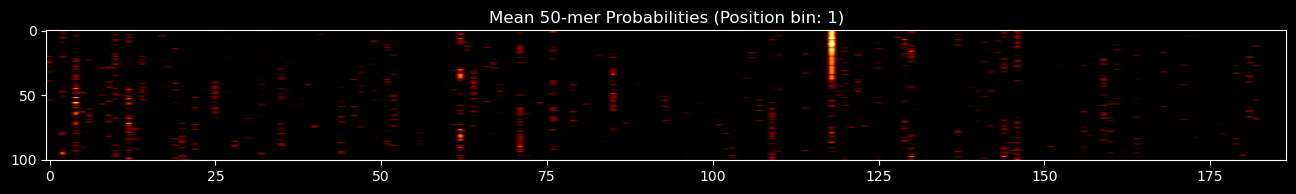

118 Yellow_fever_virus  |  20 Cercopithecine_betaherpesvirus_5


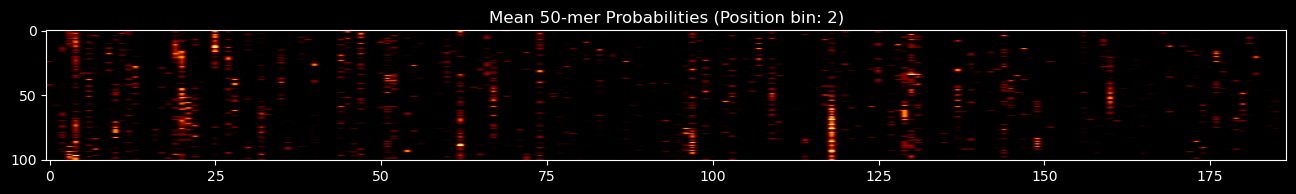

118 Yellow_fever_virus  |  143 Powassan_virus


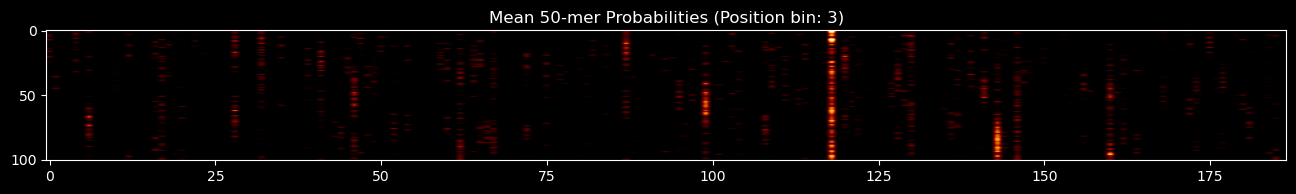

20 Cercopithecine_betaherpesvirus_5  |  62 Human_gammaherpesvirus_4


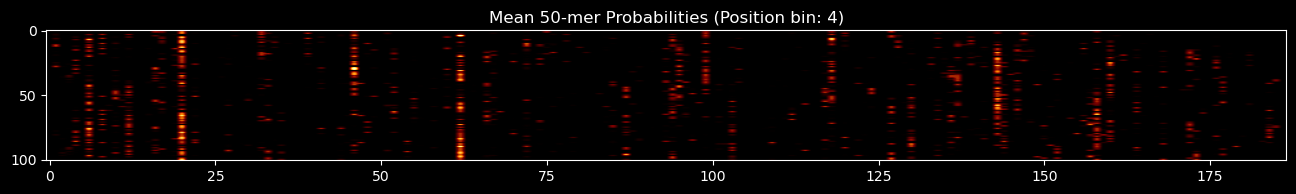

62 Human_gammaherpesvirus_4  |  32 Human_gammaherpesvirus_8


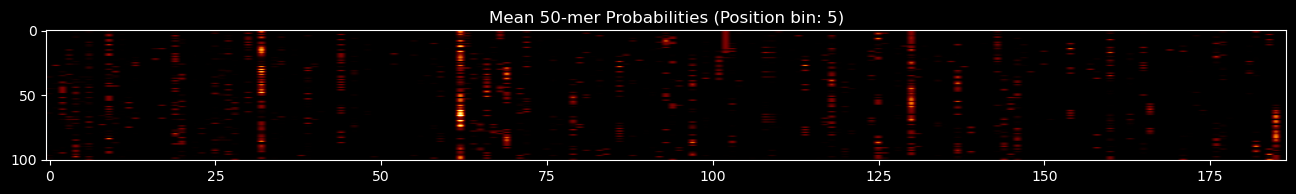

118 Yellow_fever_virus  |  62 Human_gammaherpesvirus_4


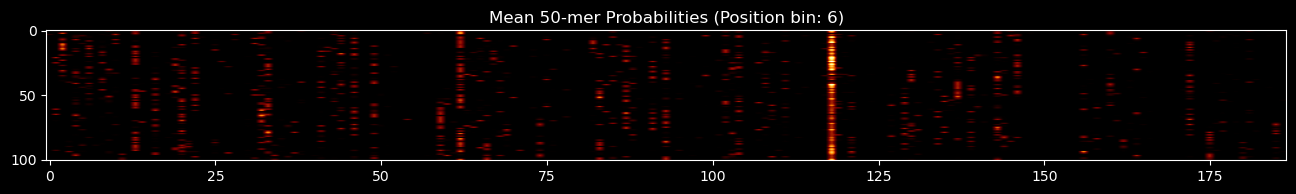

62 Human_gammaherpesvirus_4  |  118 Yellow_fever_virus


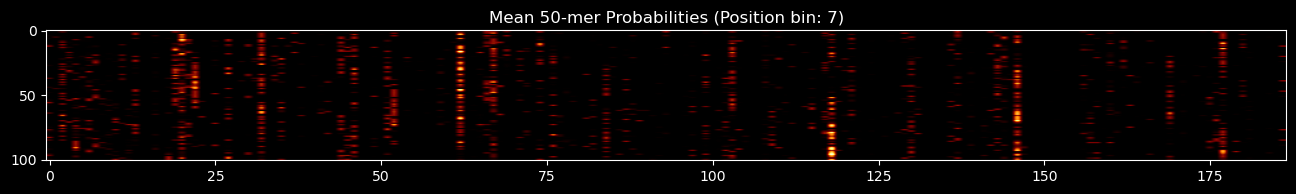

118 Yellow_fever_virus  |  62 Human_gammaherpesvirus_4


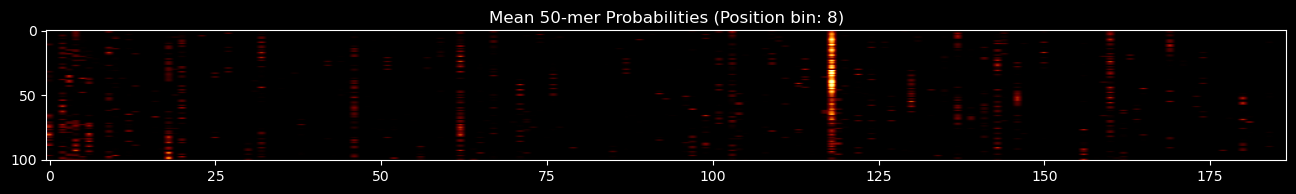

32 Human_gammaherpesvirus_8  |  62 Human_gammaherpesvirus_4


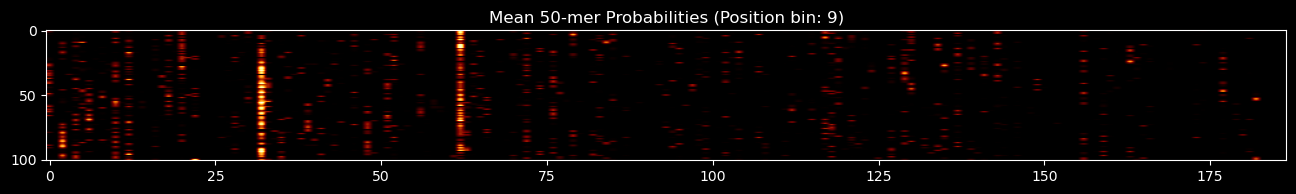

32 Human_gammaherpesvirus_8  |  25 Human_alphaherpesvirus_1


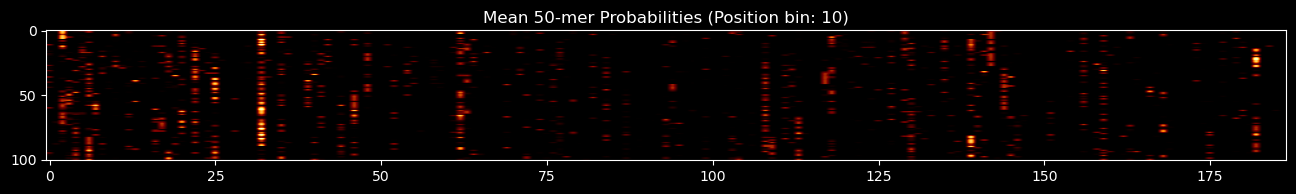

30 Human_mastadenovirus_E  |  118 Yellow_fever_virus


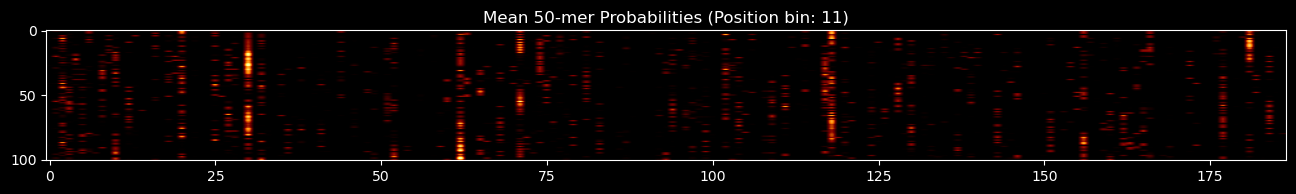

62 Human_gammaherpesvirus_4  |  10 Human_alphaherpesvirus_3


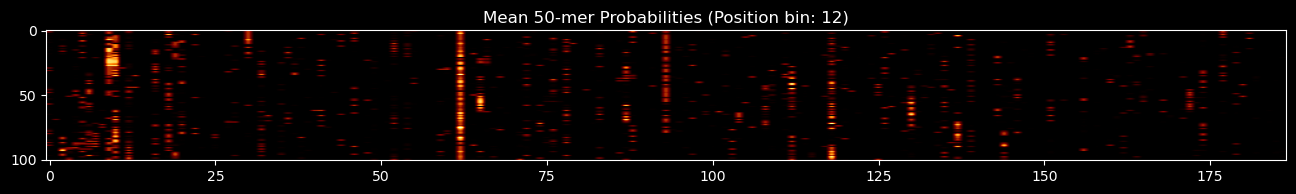

118 Yellow_fever_virus  |  10 Human_alphaherpesvirus_3


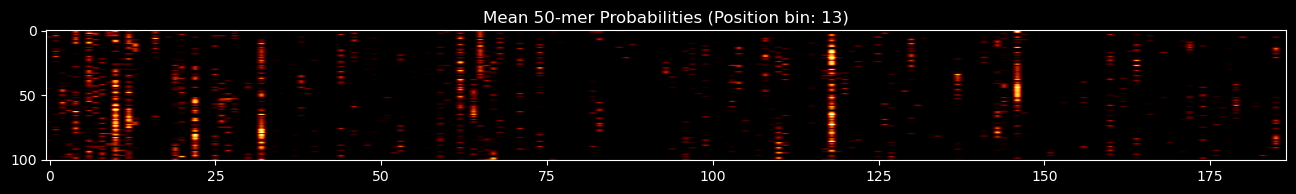

32 Human_gammaherpesvirus_8  |  146 West_Nile_virus


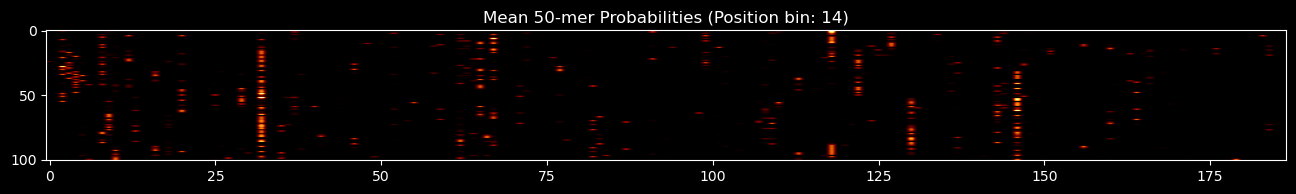

62 Human_gammaherpesvirus_4  |  118 Yellow_fever_virus


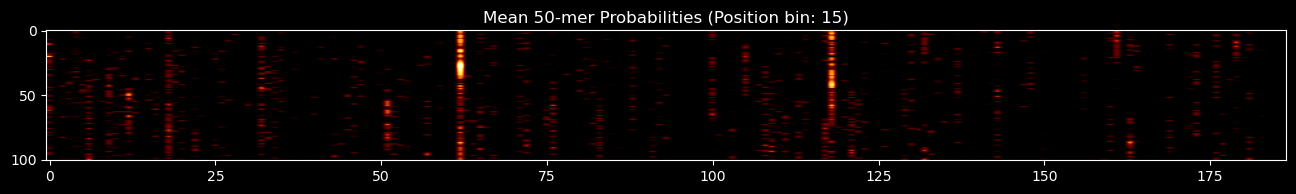

32 Human_gammaherpesvirus_8  |  62 Human_gammaherpesvirus_4


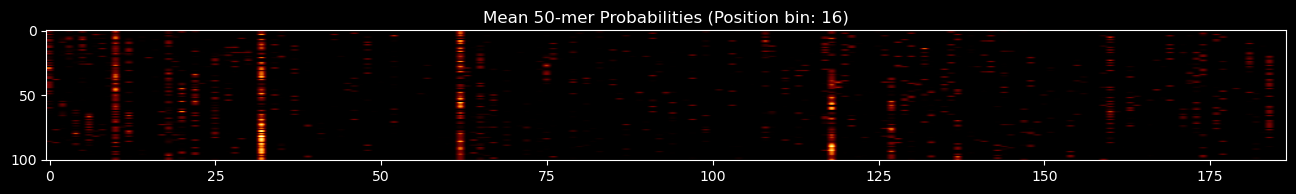

137 Japanese_encephalitis_virus  |  160 Langat_virus


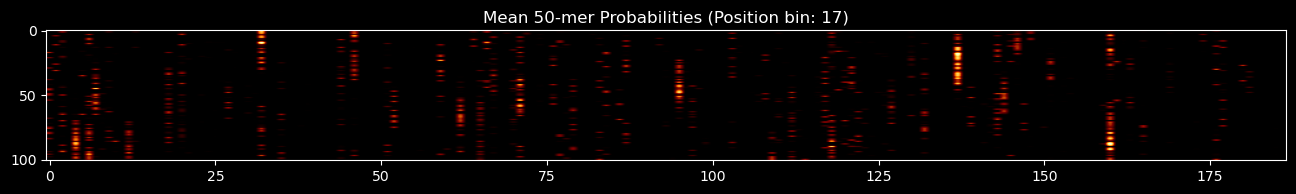

118 Yellow_fever_virus  |  62 Human_gammaherpesvirus_4


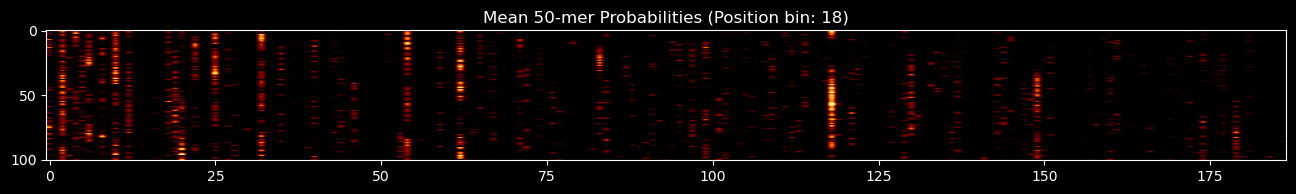

32 Human_gammaherpesvirus_8  |  20 Cercopithecine_betaherpesvirus_5


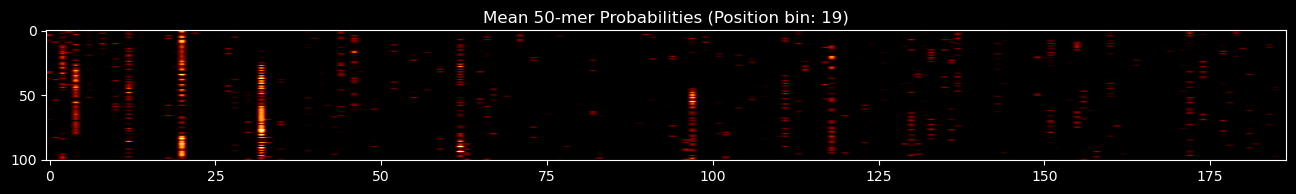

62 Human_gammaherpesvirus_4  |  4 Human_betaherpesvirus_6B


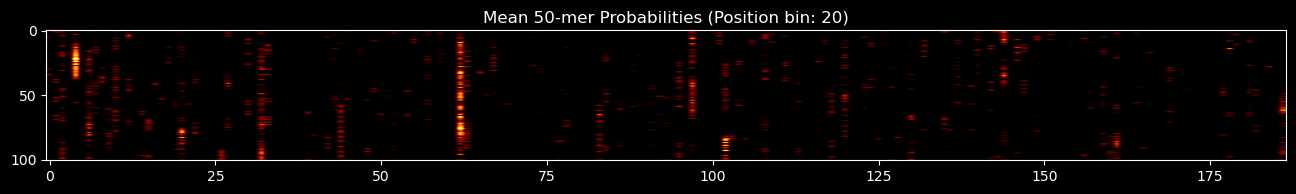

62 Human_gammaherpesvirus_4  |  137 Japanese_encephalitis_virus


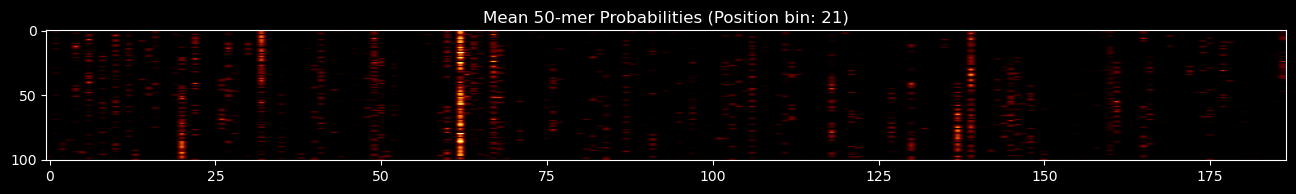

130 Zika_virus  |  62 Human_gammaherpesvirus_4


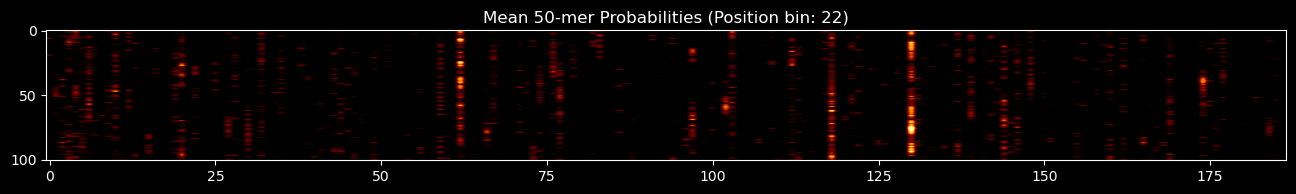

118 Yellow_fever_virus  |  2 Molluscum_contagiosum_virus


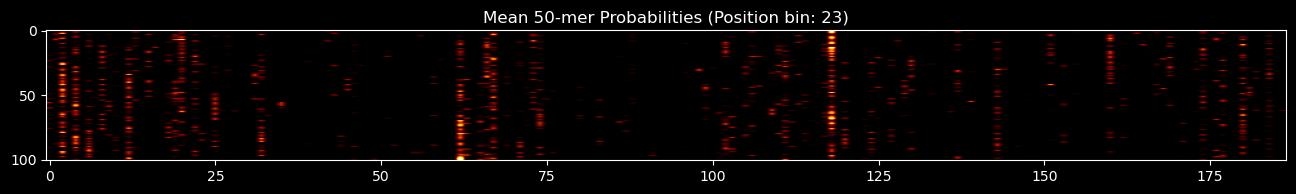

6 Human_betaherpesvirus_5  |  6 Human_betaherpesvirus_5


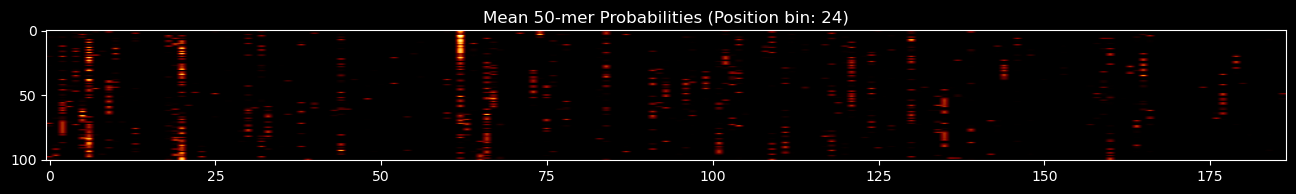

20 Cercopithecine_betaherpesvirus_5  |  32 Human_gammaherpesvirus_8


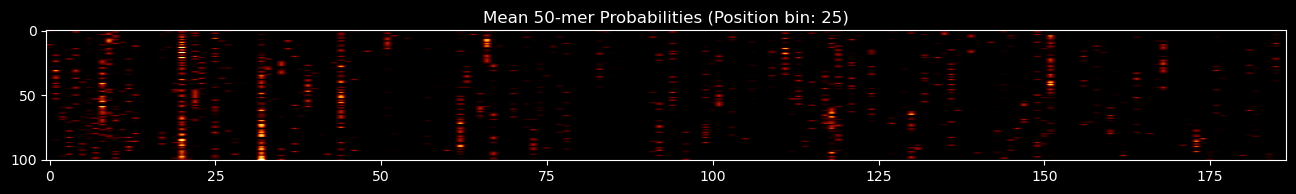

44 Venezuelan_equine_encephalitis_virus  |  2 Molluscum_contagiosum_virus


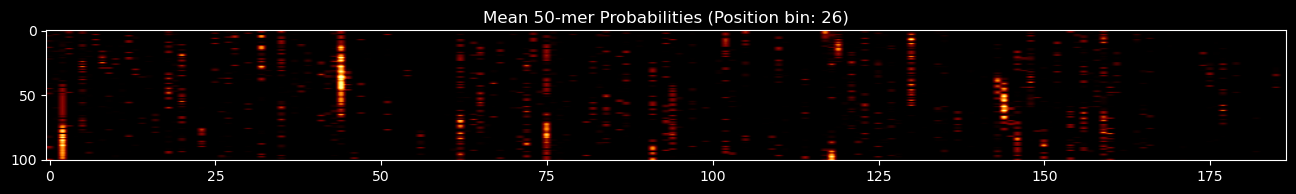

67 Louping_ill_virus  |  118 Yellow_fever_virus


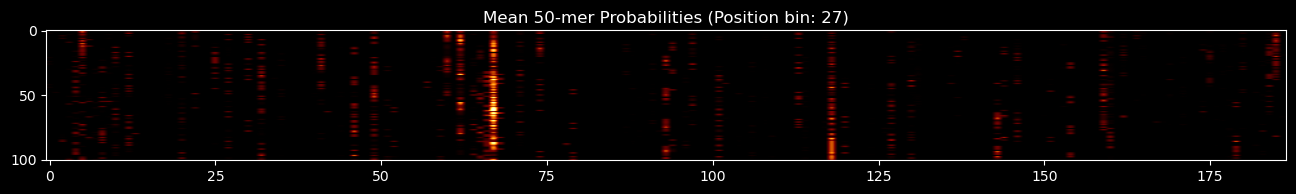

118 Yellow_fever_virus  |  20 Cercopithecine_betaherpesvirus_5


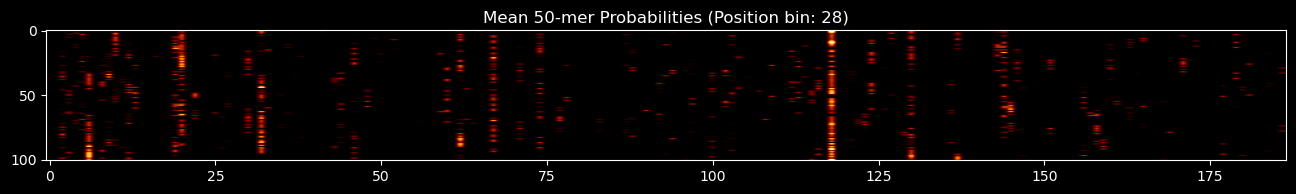

16 Hendra_henipavirus  |  6 Human_betaherpesvirus_5


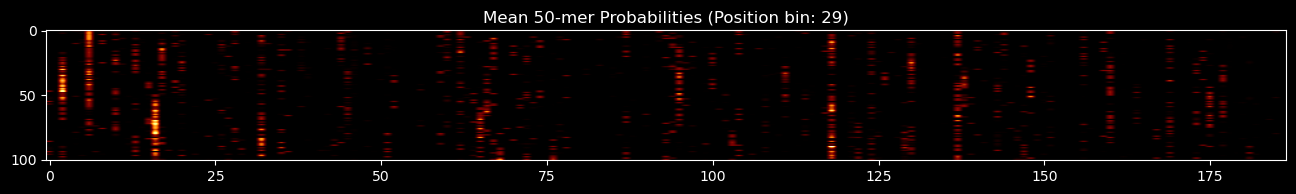

62 Human_gammaherpesvirus_4  |  9 Alphapapillomavirus_3


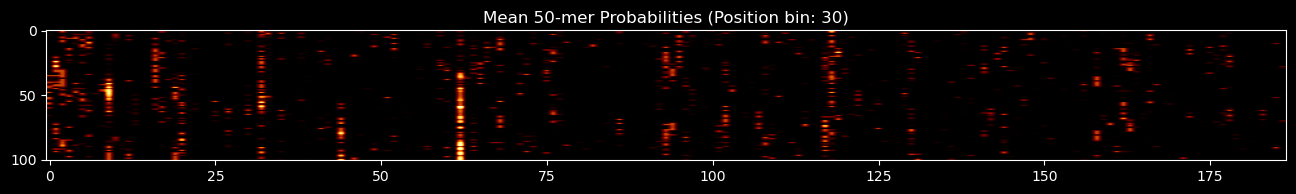

44 Venezuelan_equine_encephalitis_virus  |  20 Cercopithecine_betaherpesvirus_5


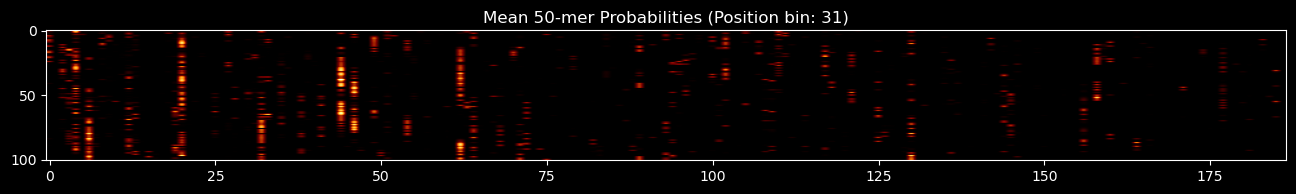

20 Cercopithecine_betaherpesvirus_5  |  32 Human_gammaherpesvirus_8


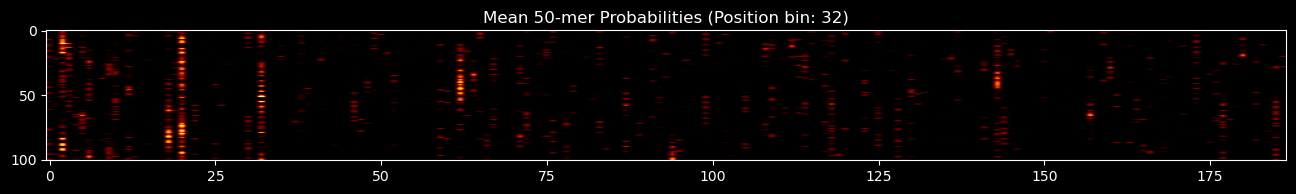

20 Cercopithecine_betaherpesvirus_5  |  144 Saint_Louis_encephalitis_virus


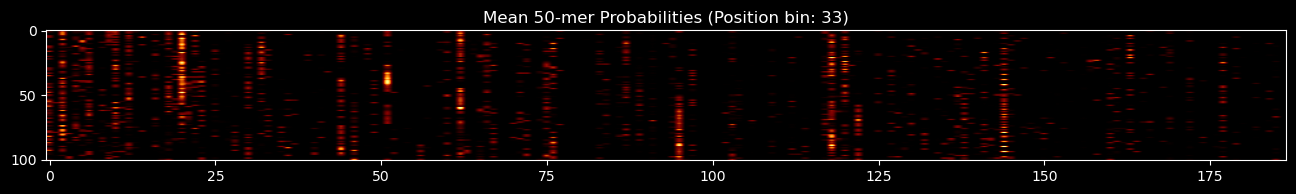

103 Murray_Valley_encephalitis_virus  |  177 Uukuniemi_phlebovirus


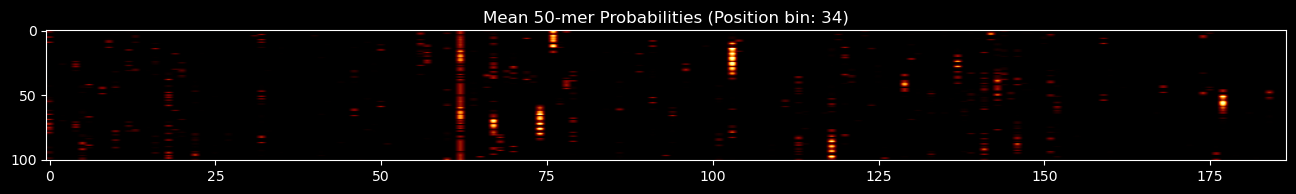

62 Human_gammaherpesvirus_4  |  12 Human_betaherpesvirus_6A


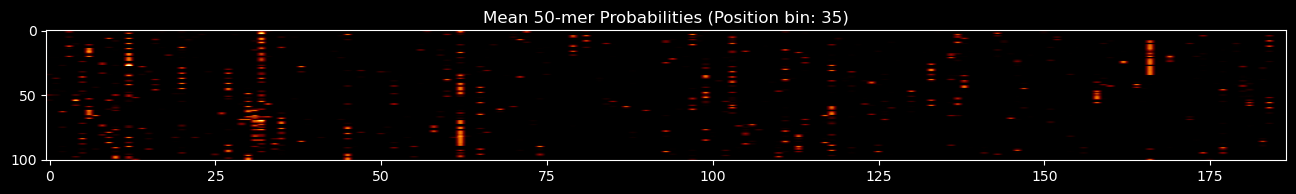

118 Yellow_fever_virus  |  62 Human_gammaherpesvirus_4


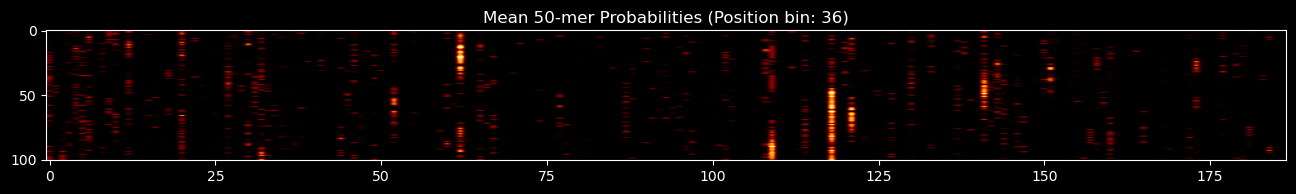

6 Human_betaherpesvirus_5  |  62 Human_gammaherpesvirus_4


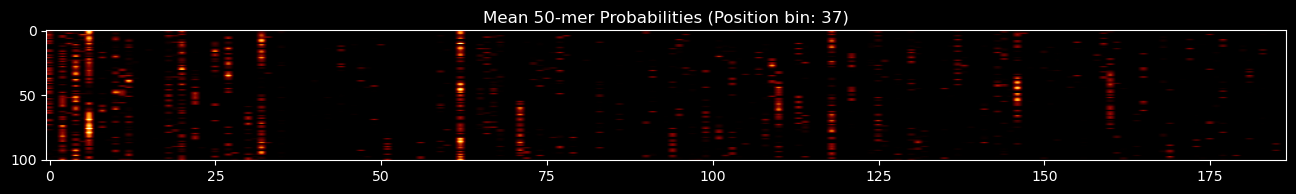

32 Human_gammaherpesvirus_8  |  62 Human_gammaherpesvirus_4


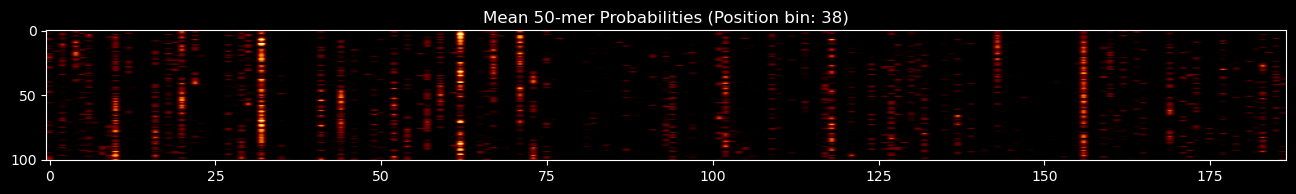

118 Yellow_fever_virus  |  71 Orf_virus


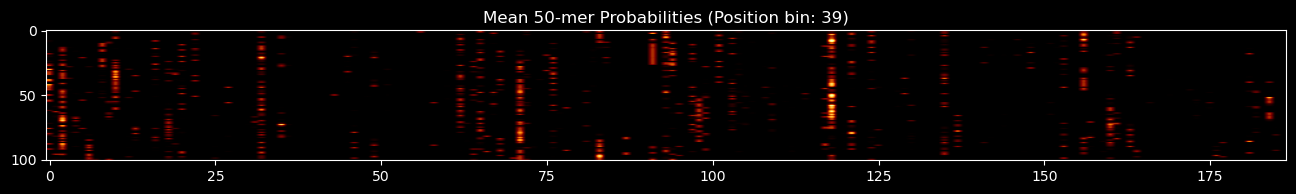

118 Yellow_fever_virus  |  4 Human_betaherpesvirus_6B


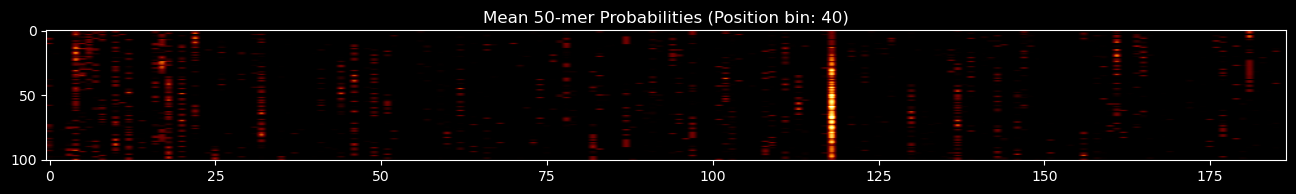

32 Human_gammaherpesvirus_8  |  102 Sindbis_virus


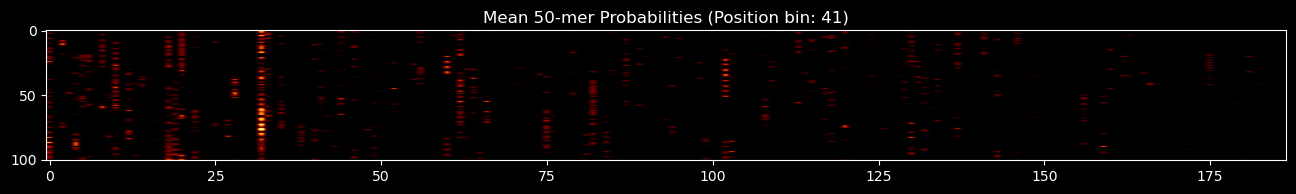

118 Yellow_fever_virus  |  32 Human_gammaherpesvirus_8


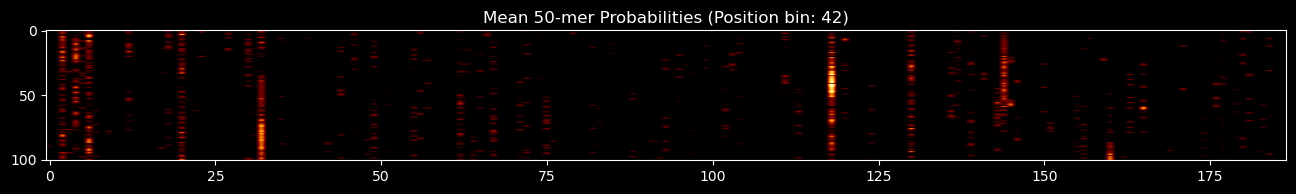

67 Louping_ill_virus  |  20 Cercopithecine_betaherpesvirus_5


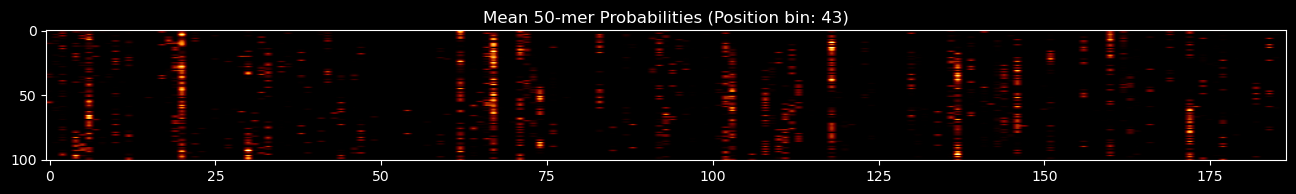

118 Yellow_fever_virus  |  143 Powassan_virus


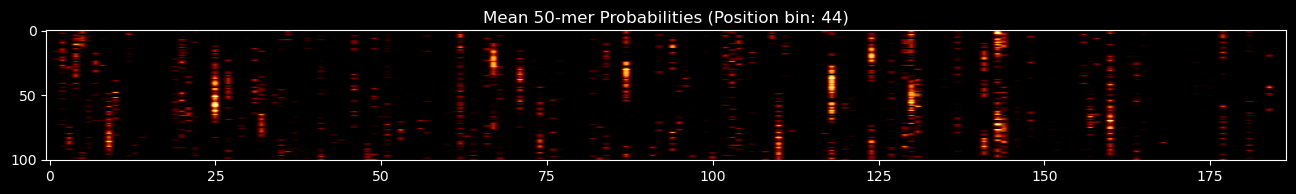

118 Yellow_fever_virus  |  62 Human_gammaherpesvirus_4


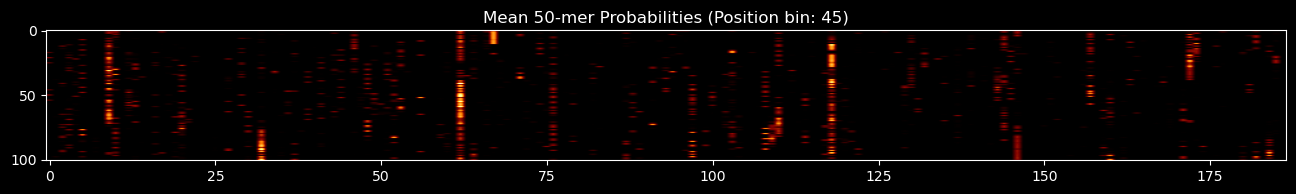

62 Human_gammaherpesvirus_4  |  44 Venezuelan_equine_encephalitis_virus


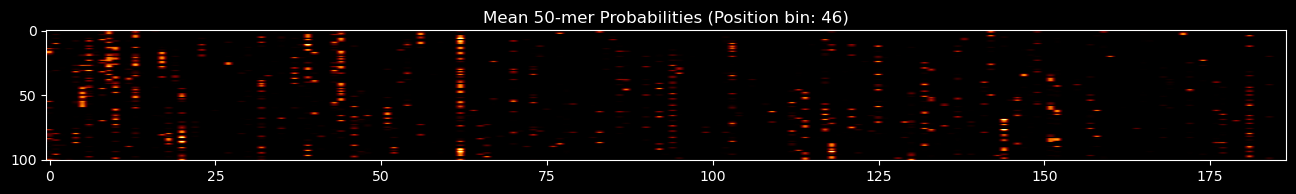

118 Yellow_fever_virus  |  160 Langat_virus


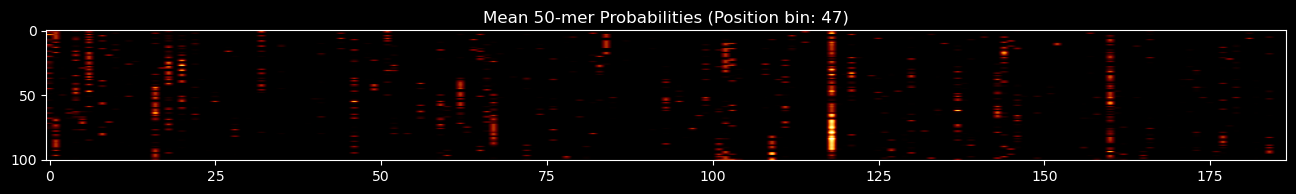

118 Yellow_fever_virus  |  62 Human_gammaherpesvirus_4


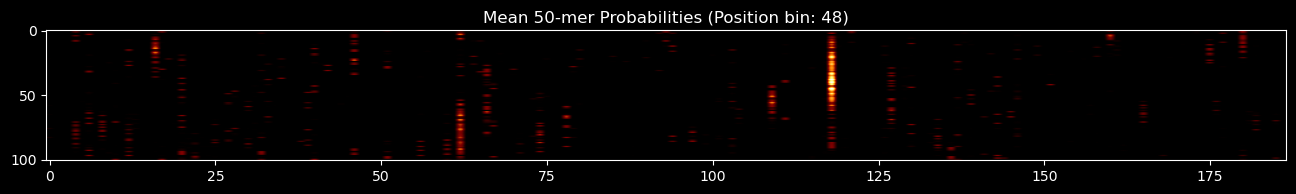

118 Yellow_fever_virus  |  32 Human_gammaherpesvirus_8


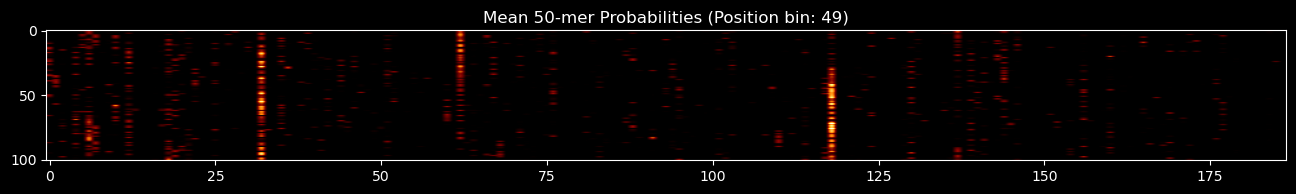

32 Human_gammaherpesvirus_8  |  62 Human_gammaherpesvirus_4


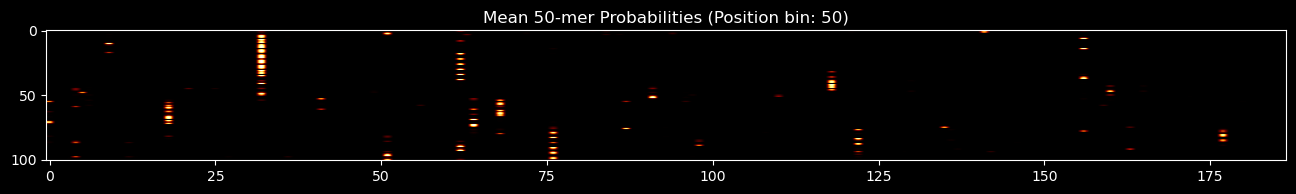

In [ ]:
o = OriginalLabels()

for pos_bin in range(1, 51):
    probs = dfdfdf.loc[(pos_bin, slice(None)), :].values
    preds = np.argmax(probs, axis=1)
    preds_significant = probs.max(axis=1) >= 0.9
    labels, counts = np.unique(preds, return_counts=True)
    pred_1 =labels[np.argmax(counts)] 
    pred_2 =labels[np.argpartition(counts, -2)[-2]] 
    print(pred_1, o.label2species(pred_1),' | ', pred_2, o.label2species(pred_2))
    plot_label_mean_probs(np.expand_dims(probs, 0), pos_bin=pos_bin)

using `asyncio`

```python
# Python
import sqlite3
import asyncio
import aiosqlite

# Create an index on refseqid
conn = sqlite3.connect('your_database.db')
c = conn.cursor()
c.execute('CREATE INDEX IF NOT EXISTS idx_refseqid ON preds_probs(refseqid);')
conn.commit()

# Use asyncio for asynchronous database queries
async def get_data(refseqid, limit, offset):
    async with aiosqlite.connect('your_database.db') as db:
        async with db.cursor() as cursor:
            await cursor.execute(f"""
                SELECT refseqid, pos_true, read_kmer_id, read_50mer_nb, prob_001, prob_002
                FROM preds_probs 
                WHERE refseqid = '{refseqid}'
                LIMIT {limit} OFFSET {offset};
            """)
            rows = await cursor.fetchall()
            return rows

# Fetch and process data in batches
async def process_data_in_batches(refseqid, batch_size):
    offset = 0
    while True:
        batch = await get_data(refseqid, batch_size, offset)
        if not batch:
            break
        # Process batch here...
        offset += batch_size

# Run the async function
asyncio.run(process_data_in_batches('11089:ncbi:1', 500))
```

In [ ]:
def plot_label_probs(probs, top_preds, true_labels=[118]):
    nb_seq, _ , nb_lbls = probs.shape
    assert nb_lbls == 187
    fig = plt.figure(figsize=(16, 2 * nb_seq - 1));
    # fig.suptitle('Suptitle')
    axs = []
    for i in range(nb_seq):
        if top_preds[i, 0] in true_labels: cmap = 'YlGn_r'
        else: cmap = 'YlOrRd_r'
        axs.append(plt.subplot2grid((nb_seq,1), (i,0), rowspan=1, colspan=1))
        # axs[i].axis('off')
        axs[i].imshow(probs[i,:,:], cmap=cmap, aspect='auto')
        axs[i].set_title(f"Seq {i+1} - Pred: {top_preds[i,0]} - Top Predictions; {top_preds[i]}")

    fig.subplots_adjust(top=1.5, bottom=0.2, hspace=0.5)
    plt.show()

# Sandbox

## Experimenting how to query the database for probabilities

In [ ]:
%%time
# Retrieve three columns filtering on a list of id
# CPU times: user 86.4 ms, sys: 27.7 ms, total: 114 ms
# Wall time: 3.03 s
query = f"""
SELECT id, read_kmer_id, read_50mer_nb
FROM label_probabilities 
WHERE id IN ({','.join([str(x) for x in range(20_000)])})
LIMIT 1000 ;
"""
# print(query)
df_probs = db.get_dataframe(query)

print(df_probs.shape)
display(df_probs.tail(5))

(1000, 3)


,id,read_kmer_id,read_50mer_nb
995,996,11089:ncbi:1-16517,1
996,997,11089:ncbi:1-16516,1
997,998,11089:ncbi:1-16515,1
998,999,11089:ncbi:1-16514,1
999,1000,11089:ncbi:1-16513,1


CPU times: user 64 ms, sys: 38.7 ms, total: 103 ms
Wall time: 3.27 s


In [ ]:
%%time
# Retrieve three columns filtering on a list of id
# CPU times: user 86.4 ms, sys: 27.7 ms, total: 114 ms
# Wall time: 3.03 s

query = f"""
SELECT id, read_kmer_id, read_50mer_nb
FROM label_probabilities 
WHERE id IN ({','.join([str(x) for x in range(20_000)])})
LIMIT 1000 ;
"""
# print(query)
df_probs = db.get_dataframe(query)

print(df_probs.shape)
display(df_probs.tail(5))

(1000, 3)


,id,read_kmer_id,read_50mer_nb
995,996,11089:ncbi:1-16517,1
996,997,11089:ncbi:1-16516,1
997,998,11089:ncbi:1-16515,1
998,999,11089:ncbi:1-16514,1
999,1000,11089:ncbi:1-16513,1


CPU times: user 1.26 ms, sys: 41.1 ms, total: 42.3 ms
Wall time: 165 ms


In [ ]:
%%time
# Retrieve all colomns filtering on a list of id
# CPU times: user 146 ms, sys: 33.2 ms, total: 179 ms
# Wall time: 3.69 s
query = f"""
SELECT *
FROM label_probabilities 
WHERE id IN ({','.join([str(x) for x in range(20000)])})
LIMIT 1000 ;
"""
# print(query)
df_probs = db.get_dataframe(query)

print(df_probs.shape)
display(df_probs.tail(5))

(1000, 190)


,id,read_kmer_id,read_50mer_nb,prob_000,prob_001,prob_002,prob_003,prob_004,prob_005,prob_006,...,prob_177,prob_178,prob_179,prob_180,prob_181,prob_182,prob_183,prob_184,prob_185,prob_186
995,996,11089:ncbi:1-16517,1,8.754474e-05,1.7678653e-21,3.634549e-05,0.0038874687,9.118338e-09,9.198738e-05,0.25078282,...,0.0004519505,2.1182933e-09,4.094599e-12,2.3100396e-18,1.3200581e-17,8.3177587e-10,9.040084e-16,1.1082036e-19,9.195436e-15,1.281601e-05
996,997,11089:ncbi:1-16516,1,7.5915164e-13,4.9807175e-17,5.303934e-15,3.7269323e-15,1.045666e-08,1.1862427e-15,2.4500586e-11,...,2.5184195e-14,2.095439e-18,9.399496e-17,3.814011e-19,6.360825e-15,1.5203839e-13,5.7828874e-19,1.778119e-17,3.0860775e-19,2.622951e-18
997,998,11089:ncbi:1-16515,1,2.7855967e-06,1.00908907e-19,1.289632e-13,1.2527812e-08,2.140582e-07,5.2963238e-11,3.072991e-08,...,4.875204e-10,1.1337102e-11,1.684754e-11,5.9170376e-18,3.030622e-19,4.96021e-18,1.8964816e-16,3.3222575e-20,1.0954248e-15,3.198112e-16
998,999,11089:ncbi:1-16514,1,1.2838345e-12,1.223785e-15,2.734925e-11,1.731637e-22,0.94311,2.3930939e-16,4.2285706e-12,...,2.3002339e-10,9.64501e-21,1.0266413e-16,3.043349e-24,4.858454e-17,9.689134e-17,5.8541106e-18,6.4746914e-27,2.3560985e-25,1.425361e-24
999,1000,11089:ncbi:1-16513,1,1.9092526e-05,4.6979976e-13,2.834131e-12,1.0610391e-06,0.117659755,1.1744167e-11,1.1163678e-14,...,8.021518e-15,7.36918e-18,6.466401e-16,3.1235835e-17,4.1697658e-18,9.649253e-16,3.6909373e-08,2.5215108e-13,8.0728805e-21,3.898578e-15


CPU times: user 167 ms, sys: 29.1 ms, total: 196 ms
Wall time: 341 ms


In [ ]:
%%time
# Retrieve 4 columns filtering on a specific read_kmer_id
# CPU times: user 25.1 ms, sys: 15.3 ms, total: 40.4 ms
# Wall time: 1.61 s

# id, read_kmer_id, read_50mer_nb, prob_001
query = f"""
SELECT id, read_kmer_id, read_50mer_nb, prob_001
FROM label_probabilities 
WHERE read_kmer_id = '11089:ncbi:1-1'
LIMIT 1000 ;
"""
# print(query)
df_probs = db.get_dataframe(query)

print(df_probs.shape)
display(df_probs.tail())

(101, 4)


,id,read_kmer_id,read_50mer_nb,prob_001
96,1755752,11089:ncbi:1-1,96,9.605288e-18
97,1756264,11089:ncbi:1-1,97,1.05488615e-20
98,1756776,11089:ncbi:1-1,98,1.7379728e-17
99,1757288,11089:ncbi:1-1,99,8.715563e-21
100,1757800,11089:ncbi:1-1,100,7.744164e-18


CPU times: user 29.5 ms, sys: 12.4 ms, total: 41.8 ms
Wall time: 1.69 s


In [ ]:
%%time
# Retrieve 4 columns filtering on a list of read_kmer_id
# CPU times: user 54.8 ms, sys: 10.1 ms, total: 64.9 ms
# Wall time: 1.82 s

# id, read_kmer_id, read_50mer_nb, prob_001
query = f"""
SELECT id, read_kmer_id, read_50mer_nb, prob_001
FROM label_probabilities 
WHERE read_kmer_id IN ('11089:ncbi:1-1', '11089:ncbi:1-2', '11089:ncbi:1-3', '11089:ncbi:1-4')
LIMIT 1000 ;
"""
# print(query)
df_probs = db.get_dataframe(query)

print(df_probs.shape)
display(df_probs.tail())

(404, 4)


,id,read_kmer_id,read_50mer_nb,prob_001
399,1755749,11089:ncbi:1-4,96,4.901561e-16
400,1756261,11089:ncbi:1-4,97,6.86821e-16
401,1756773,11089:ncbi:1-4,98,2.2368514e-14
402,1757285,11089:ncbi:1-4,99,3.8160105e-15
403,1757797,11089:ncbi:1-4,100,7.088436e-17


CPU times: user 32.1 ms, sys: 15.1 ms, total: 47.3 ms
Wall time: 4.27 s


List all indexes in the database

In [ ]:
db.list_indexes()

List of indexes in database 'single_69seq_150bp.db' and indexed columns:
- idx_preds for table 'predictions':
    - readid
    - refseqid
    - pos_true
- idx_probs for table 'label_probabilities':
    - read_kmer_id
    - read_50mer_nb


Creating a view to combine `predictions` and `label_probabilities`

In [ ]:
def create_view_preds_probs(self):
    
    # Create view joining predictions and label_probabilities
    view_name = 'preds_probs'

    # top prediction columns from table predictions:
    top_lbl_pred_n = ','.join([f"p.top_5_lbl_pred_{i}" for i in range(5)])
    print(top_lbl_pred_n)

    # probabilities columns from table label_probabilities 
    probs_n = ','.join([f"lp.prob_{i:03d}" for i in range(187)])

    query = f"""
    CREATE VIEW IF NOT EXISTS {view_name} AS
    SELECT 
        lp.id,
        p.refseqid,
        p.lbl_true, p.lbl_pred,
        p.pos_true, p.pos_pred,
        {top_lbl_pred_n},
        lp.read_kmer_id, lp.read_50mer_nb,
        {probs_n}
    FROM 
        label_probabilities lp
    INNER JOIN 
        predictions p
    ON 
        lp.read_kmer_id = p.readid
    """
    print(query)
    self.execute(query)

def drop_view_preds_probs(self):
    
    self.execute('DROP VIEW IF EXISTS preds_probs')
    
# drop_view_preds_probs(db)
# create_view_preds_probs(db)
# db.print_schema()


- 1 refseqid -> 17,000 read_kmer_id
- 1 read_kmer_id -> 101 read_50mer_nb
- 1 refseqid -> 1,717,000 read_50mer_nb

If we read in pages of 200 read_kmer_id:
- 1 refseqid -> 85 pages of 200 read_kmer_id
- 1 page of 200 read_kmer_id -> 20,200 read_50mer_nb
- each page will take about 20,200 * 3.5 ms = 70 sec

If we read in pages of 250 read_kmer_id:
- 1 refseqid -> 68 pages of 250 read_kmer_id
- 1 page of 250 read_kmer_id -> 25,250 read_50mer_nb
- each page will take about 25,250 * 3.5 ms = 88 sec

|# read_50mer_nb|wall time|wall time per row|
|---:|:---:|:---:|
|1,000|6 sec|6 ms|
|10,000|35 sec|3.5 ms|
|25,250|1 min 23 sec| 3.3 ms|
|50,000|2 min 57 sec| 3.5 ms|
|100,000|6 min 11 sec | 3.6 ms|

Seems that the page size of 25,250 is a good comprimise between speed and number of queries.


## Distance Matrix

In [ ]:
p2matrix = pfs.data / 'ncbi/other/yf/YF_2023_envelop_percentage_distance_matrix.csv'
dist_mx = pd.read_csv(p2matrix, index_col=0)
for col in dist_mx.columns:
    dist_mx[col] = dist_mx[col].str.rstrip('%').astype(float)/100
dist_mx

,YFV_Cameroon_2023,YFV_CAR_2019,U21056_senegal_1927,JX898870_senegal_1996,U23574_Senegal_1965,JX898868_Senegal_1995,JX898873_ArD149214_Senegal_2000,JX898874_ArD149194_Senegal_2000,JX898875_Senegal_2000,JX898876_Senegal_2001,...,MH666058_Brazil_2016,MF370547_Brazil_2017,MK583152_Brazil_SaoPaulo_2017,KY885001_Brazil_2017,MW308134_Brazil_2018,MK760660_Netherlands_2018,MK333805_Brazil_IlhaGrande_2018,MW308135_Brazil_2019,MZ604867_Brazil_2019,MZ712143_Brazil_2021
,,,,,,,,,,,,,,,,,,,,,
YFV_Cameroon_2023,0.00,0.04,0.19,0.19,0.19,0.19,0.19,0.19,0.19,0.19,...,0.19,0.18,0.19,0.19,0.19,0.19,0.19,0.19,0.19,0.19
YFV_CAR_2019,0.04,0.00,0.19,0.18,0.18,0.18,0.18,0.18,0.18,0.18,...,0.19,0.19,0.19,0.19,0.19,0.19,0.19,0.19,0.19,0.19
U21056_senegal_1927,0.19,0.19,0.00,0.04,0.04,0.04,0.05,0.05,0.05,0.04,...,0.15,0.15,0.15,0.15,0.15,0.15,0.15,0.15,0.15,0.15
JX898870_senegal_1996,0.19,0.18,0.04,0.00,0.03,0.00,0.03,0.03,0.03,0.03,...,0.15,0.15,0.15,0.15,0.15,0.15,0.15,0.15,0.15,0.15
U23574_Senegal_1965,0.19,0.18,0.04,0.03,0.00,0.03,0.04,0.04,0.04,0.03,...,0.15,0.15,0.15,0.15,0.15,0.15,0.15,0.15,0.15,0.15
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
MK760660_Netherlands_2018,0.19,0.19,0.15,0.15,0.15,0.15,0.15,0.15,0.15,0.15,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
MK333805_Brazil_IlhaGrande_2018,0.19,0.19,0.15,0.15,0.15,0.15,0.15,0.15,0.15,0.15,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
MW308135_Brazil_2019,0.19,0.19,0.15,0.15,0.15,0.15,0.15,0.15,0.15,0.15,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00


In [ ]:
distance_accessions = {}
missing=[]
for col in dist_mx.columns:
    regex = re.compile(r'^(?P<accession>\w{1,2}\d*)_(?P<country>.*)_(?P<year>\d\d\d\d)$')
    match = regex.search(col)
    if match: 
        accession = match.group('accession')
        subdict = {
            'accession': accession, 
            'country': match.group('country'), 
            'year': match.group('year'),
            'definition line': col
            } 
        distance_accessions[accession] = subdict
    else:
        missing =+ 1
        print(col, 'could not find the accession')

YFV_Cameroon_2023 could not find the accession
YFV_CAR_2019 could not find the accession
Yellow_fever_YF118_CAR_2018 could not find the accession


In [ ]:
included, not_included = [], []
for refseqid,v in refseq_metadata.items():
    dist_dict = distance_accessions.get(v['refseq_accession'], None)
    if dist_dict:
        included.append(v['refseq_accession'])
    else:
        not_included.append(refseqid)

print(f"{len(included)} out of 69 accessions in distance matrix, {len(not_included)} not:")
print('\n'.join([f"  - {refseq_metadata[rsid]['refseq_accession']} {refseq_metadata[rsid]['organism']}" for rsid in not_included]))

46 out of 69 accessions in distance matrix, 23 not:
  - DQ235229 Ethiopia_1961
  - MF405338 Ghana_Hsapiens_1927
  - JX898871 ArD114896_Senegal_1995
  - JX898872 Senegal_Aedes-aegypti_1995
  - DQ118157 Spain_Vaccine_2004
  - JX898879 ArD181676_Senegal_2005
  - JX898881 Senegal_Aedes_luteocephalus_2005
  - JX898880 ArD181564_Senegal_2005
  - MK457701 Nigeria_Hsapiens_2018
  - JF912183 Brazil_Hsapiens_1984
  - KM388817 Venezuela_Guarico_Allouetta_seniculus_2004
  - KM388816 Venezuela_Monagas_Asiniculus_2010
  - MK583166 Brazil_SaoPaulo_Hsapiens_2018
  - MK760665 Netherlands_Hsapiens-from-brazil_2018
  - MF370535 Brazil_Allouatta_sp_2016
  - MF370533 Brazil_Hsapiens_2017
  - MF370530 Brazil_Haemagogus-janthinomys_2017
  - MW960207 Yellow_fever_YF118_CAR_2018
  - KY495641 China_Hsapiens_2016
  - KX268355 China_Hsapiens_2016
  - KY587416 China_Hsapiens_2016
  - MF004383 432429_S4_MF004383
  - MW960207 yp


In [ ]:
list_included_refeseqs = [f"{meta['refseqid']},{meta['refseq_accession']},{meta['organism']}" for meta in refseq_metadata.values() if meta['refseq_accession'] in included]
p2inclrefseqs = pfs.data / 'ncbi/other/yf/YF_2023-accessions-in-ds-and-distance-matrix.csv'
with open(p2inclrefseqs, 'w') as f:
    f.write('refseqid,refseq_accession,organism\n')
    f.write('\n'.join(list_included_refeseqs))

pd.read_csv(p2inclrefseqs).head(3)

,refseqid,refseq_accession,organism
0,11089:ncbi:1,AY968064,Angola_1971
1,11089:ncbi:2,U54798,Ivory_Coast_1982
2,11089:ncbi:4,AY572535,Gambia_2001


In [ ]:
for selected in selected_refseqs:
    accession = refseq_metadata[selected]['refseq_accession']
    print(f"{selected:14s}    {refseq_metadata[selected]['organism']:25s}    {refseq_metadata[selected]['refseq_accession']:20s}   {distance_accessions[accession]['definition line']:30s}")

11089:ncbi:10     Peru_Hsapiens_2007           GQ379163               GQ379163_Peru_2007            
11089:ncbi:13     Sudan_Hsapiens_1941          KU978764               KU978764_Sudan_1941           
11089:ncbi:30     Nigeria_Hsapiens_1946        KU978763               KU978763_Nigeria_1946         
11089:ncbi:37     Brazil_Hsapiens_2002         JF912190               JF912190_Brazil_2002          
11089:ncbi:32     Brazil_Hsapiens_1983         JF912181               JF912181_Brazil_1983          
11089:ncbi:35     Brazil_Hsapiens_1984         JF912182               JF912182_Brazil_1984          
11089:ncbi:1      Angola_1971                  AY968064               AY968064_angola_1971          


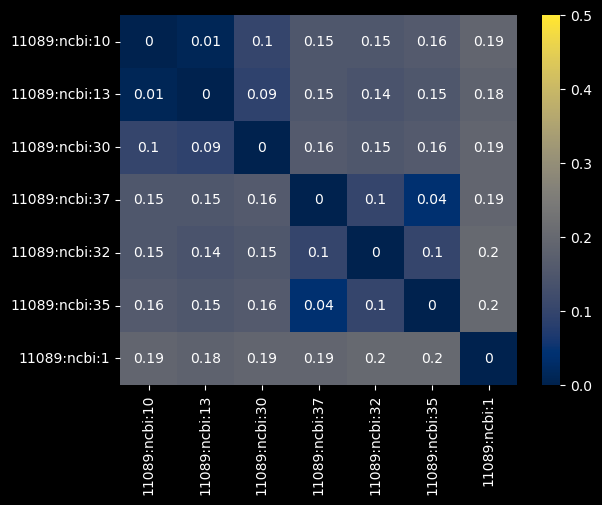

In [ ]:
refseqid2dist_mx_idx = {}
dist_mx_idx2refseqid = {}

for refseqid in selected_refseqs:
    accession = refseq_metadata[refseqid]['refseq_accession']
    idx = distance_accessions[accession]['definition line']
    refseqid2dist_mx_idx[refseqid] = idx
    dist_mx_idx2refseqid[idx] = refseqid

selected_dist_idxs = [refseqid2dist_mx_idx[rsid] for rsid in selected_refseqs]
selected_dist = dist_mx.loc[selected_dist_idxs, selected_dist_idxs]
selected_dist.index=selected_refseqs
selected_dist.columns=selected_refseqs
sns.heatmap(selected_dist, cmap='cividis', annot=True, vmin=0, vmax=0.5);

Accuracy vs Distance

In [ ]:
%%time
df_reads = db.get_dataframe('SELECT id, refseqid, lbl_true, lbl_pred, pos_true FROM predictions')
df_reads.shape

CPU times: user 112 ms, sys: 27.2 ms, total: 139 ms
Wall time: 4.45 s


(53248, 5)

In [ ]:
df_reads['accuracy'] = df_reads.lbl_pred == df_reads.lbl_true

In [ ]:
bins = [0 + n * 10237/n_position_bins for n in range(n_position_bins+1)]
df_reads['pos_bin'] = pd.cut(df_reads['pos_true'], bins, retbins=False)
df_reads['pos_bin'].cat.categories = range(1, n_position_bins+1) # rename categories from 1 to n_position_bins

In [ ]:
df_reads.head()

,id,refseqid,lbl_true,lbl_pred,pos_true,accuracy,pos_bin
0,1,11089:ncbi:1,118,10,7804,False,39
1,2,11089:ncbi:1,118,2,6069,False,30
2,3,11089:ncbi:1,118,144,5317,False,26
3,4,11089:ncbi:1,118,32,1717,False,9
4,5,11089:ncbi:1,118,118,9658,True,48


In [ ]:
r_group = df_reads.groupby('refseqid')
r_acc_sum = r_group['accuracy'].sum()
r_counts = r_group['accuracy'].count().replace(0,1)
r_acc_mean = r_acc_sum.div(r_counts)
# display(r_acc_mean)

bin_group = df_reads.groupby(['refseqid','pos_bin'])
bin_acc_mean = bin_group.mean().loc[(slice(None),slice(None)), ['accuracy']]
# bin_acc_mean

In [ ]:
set(selected_dist.index).difference(set(selected_refseqs))

set()

In [ ]:
common_refseqid = list(set(df_reads.refseqid.unique()).intersection(set(selected_refseqs)))

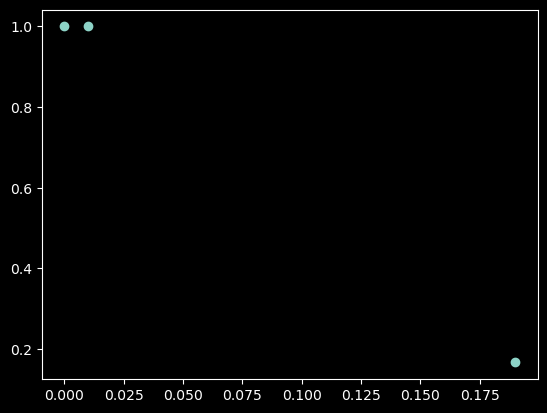

In [ ]:
plt.scatter(x=selected_dist.loc[common_refseqid[2], common_refseqid], y=r_acc_mean.loc[common_refseqid]);

## Successive predictions

#### Successive identical predictions (integer)

To evaluate and compare multiple lists of integers based on the criteria you've described, you can use a custom scoring function that takes into account both the number of elements equal to the given value y and the length of sequences of identical elements. Here's a suggested approach using a mathematical function as a metric:

Proposed Scoring Function

Let's define a scoring function S(L, y) for a list L and target value y:
```
S(L, y) = (C / N) * (1 + (M / N) * (1 - F / C))
```
Where:
- N is the total number of elements in the list
- C is the count of elements equal to y
- M is the maximum length of any continuous sequence of y in the list
- F is the number of "fragments" or separate sequences of y in the list

Explanation of the Function Components

1. (C / N): This represents the proportion of elements in the list that are equal to y. It ranges from 0 to 1.

2. (1 + (M / N) * (1 - F / C)): This factor rewards longer sequences and penalizes fragmentation.
   - (M / N) rewards longer continuous sequences of y
   - (1 - F / C) penalizes fragmentation; it's 1 when there's only one sequence (F = 1) and decreases as the number of fragments increases

Properties of the Scoring Function

1. The score will be highest (1.0) when all elements are equal to y (C = N, M = N, F = 1).
2. For the same number of matching elements (C), lists with longer continuous sequences will score higher.
3. For the same number of matching elements (C) and maximum sequence length (M), lists with fewer fragments will score higher.

Example Calculations

Let's say y = 1 and we have the following lists:

1. [1, 1, 1, 1, 1] (N=5, C=5, M=5, F=1)
   S = (5/5) * (1 + (5/5) * (1 - 1/5)) = 1 * (1 + 1 * 0.8) = 1.8

2. [1, 1, 1, 0, 1] (N=5, C=4, M=3, F=2)
   S = (4/5) * (1 + (3/5) * (1 - 2/4)) = 0.8 * (1 + 0.6 * 0.5) = 1.04

3. [1, 0, 1, 0, 1] (N=5, C=3, M=1, F=3)
   S = (3/5) * (1 + (1/5) * (1 - 3/3)) = 0.6 * 1 = 0.6

This scoring function provides a single metric that you can use to evaluate and compare multiple lists based on your specified criteria. The higher the score, the better the list matches your requirements.

[ref](https://www.perplexity.ai/search/successive-integers-scoring-pxKaeZFQQWGuvgiXuXPAGw)

### Successive close probabilities (float)

To evaluate your lists of probabilities based on the criteria you've described, you can use a custom scoring function that takes into account both the individual values and their sequence. Here's a suggested approach:

## Proposed Scoring Function

You can use a combination of techniques to create a scoring function that meets your requirements:

1. Average proximity to 1
2. Longest sequence bonus
3. Weighted scoring

Here's a Python function that implements this approach:

```python
import numpy as np

def score_probability_list(prob_list, sequence_threshold=0.9, sequence_weight=0.3):
    # Convert to numpy array for easier operations
    probs = np.array(prob_list)
    
    # 1. Calculate average proximity to 1
    base_score = np.mean(probs)
    
    # 2. Find the longest sequence of numbers above the threshold
    sequence_length = 0
    max_sequence = 0
    for prob in probs:
        if prob >= sequence_threshold:
            sequence_length += 1
            max_sequence = max(max_sequence, sequence_length)
        else:
            sequence_length = 0
    
    # Normalize the sequence bonus
    sequence_bonus = max_sequence / len(probs)
    
    # 3. Combine the scores with weighting
    final_score = (1 - sequence_weight) * base_score + sequence_weight * sequence_bonus
    
    return final_score
```

## How It Works

1. **Average proximity to 1**: This is simply the mean of all probabilities in the list. It ensures that lists with many elements close to 1 get a good score.

2. **Longest sequence bonus**: This part finds the longest continuous sequence of probabilities above a certain threshold (default 0.9). It's then normalized by dividing by the list length.

3. **Weighted scoring**: The final score is a weighted combination of the average proximity and the sequence bonus. You can adjust the `sequence_weight` to give more or less importance to the sequence aspect.

## Usage and Customization

You can call this function like this:

```python
list1 = [0.9, 0.95, 0.98, 0.99, 0.7, 0.8]
list2 = [0.7, 0.8, 0.9, 0.95, 0.98, 0.99]

score1 = score_probability_list(list1)
score2 = score_probability_list(list2)

print(f"Score for list1: {score1}")
print(f"Score for list2: {score2}")
```

You can customize the function by adjusting:

- `sequence_threshold`: The minimum value to consider as part of a "good" sequence.
- `sequence_weight`: How much importance to give to the sequence bonus vs. the average proximity.

## Advantages

This scoring function:
- Rewards lists with many elements close to 1
- Gives a bonus for longer sequences of high probabilities
- Is flexible and can be easily adjusted to emphasize different aspects

Remember to test this function with various input lists to ensure it behaves as expected for your specific use case.

# End of Section